In [ ]:
import numpy as np
import pandas as pd

import io
from contextlib import redirect_stdout

import torch
import torch.nn as nn



import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.ticker as ticker

# Load DCIts
import sys
sys.path.append('../..')


# Load utils
from src.utils import *

# Set random seeds for reproducibility
seed = 42

torch.cuda.is_available()

# Check if CUDA is available
if torch.cuda.is_available():
    # Specify the device (index starts from 0, so cuda:0 is the first GPU)
    device = torch.device("cuda:0")
    print(f"Using {torch.cuda.get_device_name(device)}")
else:
    print("CUDA is not available. Using CPU instead.")
    device = torch.device("cpu")

Using NVIDIA GeForce RTX 5070


# Helper functions:

In [64]:
def time_series_hidden_trend(
    mean,
    ts_length,
    A=1.0,
    P=200,
    rho_U=0.3,
    sigma_U=0.1,
    sigma_X=0.1,
    sigma_Y=0.1,
    sigma_Z=0.1,
    burn_in=1000,
    seed=None,
):
    if seed is not None:
        np.random.seed(seed)

    total_length = ts_length + burn_in
    time_series = torch.zeros(4, total_length)

    # Initial values
    time_series[:, 0:2] = torch.tensor(
        np.random.normal(0, 1, (4, 2)),
        dtype=torch.float32,
    )

    for t in range(2, total_length):
        U_prev = time_series[0, t - 1]
        X_prev = time_series[1, t - 1]
        Y_prev = time_series[2, t - 1]
        Z_prev = time_series[3, t - 1]
        U_lag2 = time_series[0, t - 2]

        eta_U = np.random.normal(mean, sigma_U)
        eta_X = np.random.normal(mean, sigma_X)
        eta_Y = np.random.normal(mean, sigma_Y)
        eta_Z = np.random.normal(mean, sigma_Z)

        seasonal_drive = A * np.sin(2 * np.pi * t / P)

        time_series[0, t] = seasonal_drive + rho_U * U_prev + eta_U
        time_series[1, t] = 0.6 * X_prev + 0.8 * U_prev + eta_X
        time_series[2, t] = 0.5 * Y_prev + 0.8 * U_lag2 + eta_Y
        time_series[3, t] = 0.4 * Z_prev + 0.7 * X_prev + eta_Z

    return time_series[:, burn_in:]


def lag_accuracy_table(stats, ground_truth_alpha, alpha_key=1, names=None):
    alpha_mean = stats["alpha"][alpha_key]["mean"]
    ground_truth_alpha_np = ground_truth_alpha.detach().cpu().numpy()

    # Learned alpha is flipped to align lag index 0 with physical lag 1.
    alpha_for_lags = np.flip(alpha_mean, axis=2)

    rows = []
    true_links = np.argwhere(ground_truth_alpha_np != 0)

    for target_idx, source_idx, true_lag_idx in true_links:
        estimated_lag_values = alpha_for_lags[target_idx, source_idx]
        best_lag_idx = np.argmax(np.abs(estimated_lag_values))

        rows.append({
            "source": names[source_idx] if names is not None else source_idx + 1,
            "target": names[target_idx] if names is not None else target_idx + 1,
            "true_lag": true_lag_idx + 1,
            "estimated_best_lag": best_lag_idx + 1,
            "correct_lag": best_lag_idx == true_lag_idx,
            "ground_truth_alpha": ground_truth_alpha_np[target_idx, source_idx, true_lag_idx],
            "estimated_alpha_true_lag": estimated_lag_values[true_lag_idx],
            "estimated_alpha_best_lag": estimated_lag_values[best_lag_idx],
        })

    return pd.DataFrame(rows)


def make_false_positive_table(stats, ground_truth_alpha, names, alpha_key=1, threshold=0.04):
    alpha_mean = np.flip(stats["alpha"][alpha_key]["mean"], axis=2)
    alpha_std = np.flip(stats["alpha"][alpha_key]["std"], axis=2)
    alpha_gt = ground_truth_alpha.detach().cpu().numpy()

    stable_mask = (
        (np.abs(alpha_mean) > 1.95 * alpha_std)
        & (np.abs(alpha_mean) >= threshold)
    )
    false_positive_mask = stable_mask & (alpha_gt == 0)

    rows = []

    for target_idx, source_idx, lag_idx in np.argwhere(false_positive_mask):
        mean_alpha = alpha_mean[target_idx, source_idx, lag_idx]

        rows.append({
            "source": names[source_idx],
            "target": names[target_idx],
            "lag": lag_idx + 1,
            "mean_alpha": mean_alpha,
            "std_alpha": alpha_std[target_idx, source_idx, lag_idx],
            "_abs_alpha": abs(mean_alpha),
        })

    table = pd.DataFrame(rows)

    if len(table) > 0:
        table = (
            table
            .sort_values("_abs_alpha", ascending=False)
            .groupby(["source", "target"], as_index=False)
            .first()
            .sort_values("_abs_alpha", ascending=False)
            .drop(columns="_abs_alpha")
        )

    return table

# Parameters:



$$
\begin{array}{l}
T \in \{1000, 5000, 20000\}, \quad L \in \{5, 10\} \\
\sigma_{\eta} \in \{0.05, 0.1, 0.2, 0.5\}
\end{array}
$$



$$
L \geq \tau_{\max}
$$

In [6]:
mean = 0
sigma_U = 0.1
sigma_X = 0.05
sigma_Y = 0.2
sigma_Z = 0.5
ts_length = 20000
burn_in = 1000

A_control = 0
A = [0.5, 1.0, 2.0]
P = [50, 200, 500] 
rho_U = [0, 0.3, 0.7]



no_of_timeseries_gp = 4
window_length_gp = 5
rho_U_current = rho_U[1]

# Observed U: model sees U, X, Y, Z
# 0 = U, 1 = X, 2 = Y, 3 = Z
ground_truth_alpha = torch.zeros(no_of_timeseries_gp, no_of_timeseries_gp, window_length_gp)

ground_truth_alpha[0, 0, 0] = rho_U_current

ground_truth_alpha[1, 1, 0] = 0.6
ground_truth_alpha[1, 0, 0] = 0.8

ground_truth_alpha[2, 2, 0] = 0.5
ground_truth_alpha[2, 0, 1] = 0.8

ground_truth_alpha[3, 3, 0] = 0.4
ground_truth_alpha[3, 1, 0] = 0.7

alpha_mask = (ground_truth_alpha != 0).float()
ground_truth_bias = torch.zeros(no_of_timeseries_gp)



# Hidden U case: model sees only X, Y, Z
# 0 = X, 1 = Y, 2 = Z
ground_truth_alpha_hidden_U = torch.zeros(3, 3, window_length_gp)

# X_t = 0.6 X_{t-1} + hidden U contribution + noise
ground_truth_alpha_hidden_U[0, 0, 0] = 0.6

# Y_t = 0.5 Y_{t-1} + hidden U contribution + noise
ground_truth_alpha_hidden_U[1, 1, 0] = 0.5

# Z_t = 0.4 Z_{t-1} + 0.7 X_{t-1} + noise
ground_truth_alpha_hidden_U[2, 2, 0] = 0.4
ground_truth_alpha_hidden_U[2, 0, 0] = 0.7

alpha_mask_hidden_U = (ground_truth_alpha_hidden_U != 0).float()
ground_truth_bias_hidden_U = torch.zeros(3)


Time series:

$$
\begin{split}
U_{t} &= A \sin \left( \frac{2 \pi t}{P} \right) + \rho_{U} U_{t-1} + \eta_{t}^{U}, \\
X_{t} &= 0.6 X_{t-1} + 0.8 U_{t-1} + \eta_{t}^{X}, \\
Y_{t} &= 0.5 Y_{t-1} + 0.8 U_{t-2} + \eta_{t}^{Y}, \\
Z_{t} &= 0.4 Z_{t-1} + 0.7 X_{t-1} + \eta_{t}^{Z}.
\end{split}
$$

Parameter possible values:
$$
\begin{array}{l}
A \in \{0.5, 1.0, 2.0\}, \quad P \in \{50, 200, 500\}, \quad \rho_{U} \in \{0, 0.3, 0.7\} \\
\eta_{t}^{k} \sim \mathcal{N}(0, \sigma_{k}^{2}), \quad k \in \{U, X, Y, Z\}
\end{array}
$$

ground-truth dependencies:

$$
\begin{array}{c}
U_{t-1} \rightarrow X_{t}, \quad U_{t-2} \rightarrow Y_{t}, \quad X_{t-1} \rightarrow Z_{t} \\
X_{t-1} \rightarrow X_{t}, \quad Y_{t-1} \rightarrow Y_{t}, \quad Z_{t-1} \rightarrow Z_{t}, \quad U_{t-1} \rightarrow U_{t} \text{ (if } \rho_{U} \neq 0)
\end{array}
$$

# Control case:

In [10]:
time_series = time_series_hidden_trend(
    mean=mean,
    ts_length=ts_length,
    A=A_control,
    P=P[0],
    rho_U=rho_U[1],
    sigma_U=sigma_U,
    sigma_X=sigma_X,
    sigma_Y=sigma_Y,
    sigma_Z=sigma_Z,
    burn_in=burn_in,
    seed=seed,
)

time_series_observed_U = time_series # U, X, Y, Z
time_series_hidden_U = time_series_observed_U[1:, :]  # X, Y, Z

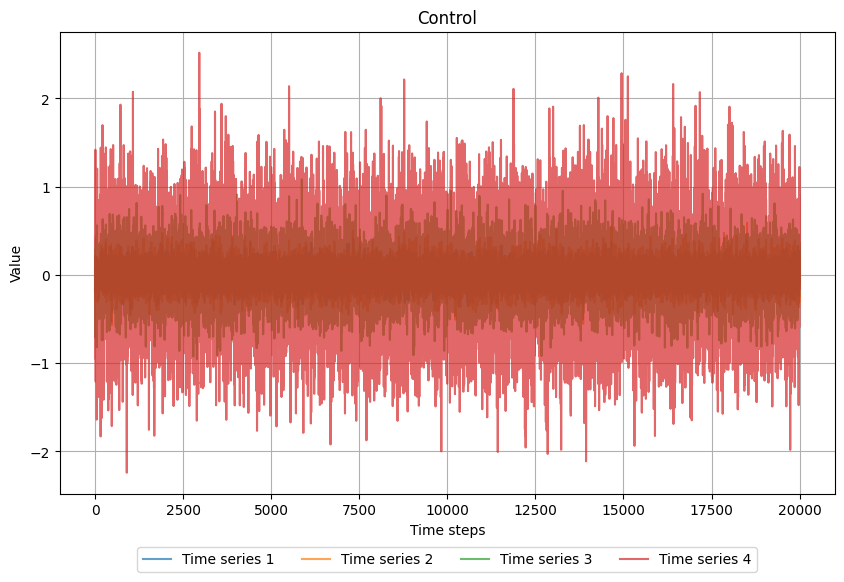

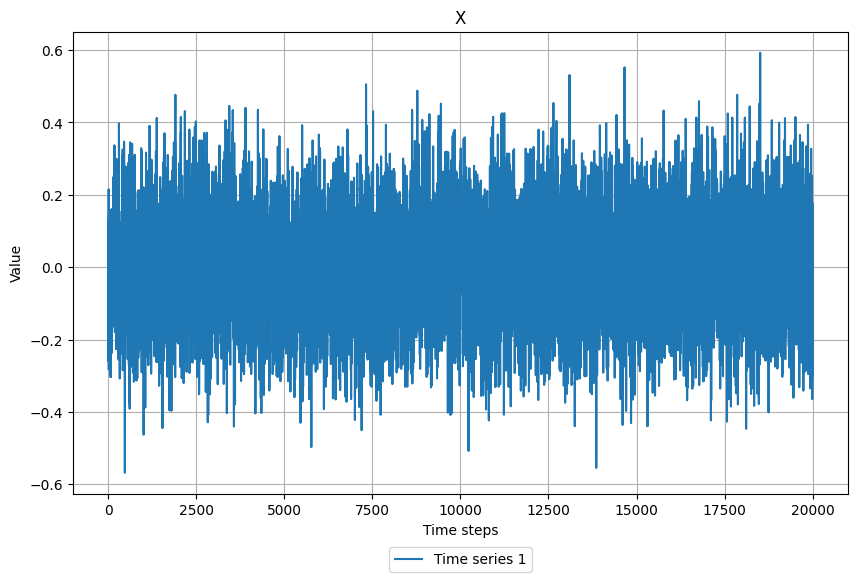

In [31]:
plot_ts(time_series_observed_U, dataset_name='Control',alpha=0.7)

#plot_ts(time_series_observed_U[:1,:], dataset_name='U',alpha=1) # U
plot_ts(time_series_observed_U[1:2,:], dataset_name='X',alpha=1) # X
#plot_ts(time_series_observed_U[2:3,:], dataset_name='Y',alpha=1) # Y
#plot_ts(time_series_observed_U[3:4,:], dataset_name='Z',alpha=1) # Z



In [12]:
train_config = {
    'verbose': False,
    'device' : device,
    'learning_rate': 1e-3,
    'scheduler_patience': 5,
    'early_stopping_modifier': 2,
    'criterion': nn.MSELoss() # MSE
    #'criterion': nn.L1Loss() # MAE
}

In [13]:
# Collect results from multiple runs
results = collect_multiple_runs(
    n_runs=5,
    time_series=time_series_observed_U,
    window_size=5,
    temperature=1.0,
    order=[1,1],
    config=train_config,
    verbose=True
)

stats = calculate_multiple_run_statistics(results)

Training Configuration:
  verbose: False
  device: cuda:0
  learning_rate: 0.001
  scheduler_patience: 5
  early_stopping_modifier: 2
  criterion: MSELoss()
Starting Run 1/5
Run 1 completed. Test Loss: 7.476181e-02
Starting Run 2/5
Run 2 completed. Test Loss: 7.471026e-02
Starting Run 3/5
Run 3 completed. Test Loss: 7.482755e-02
Starting Run 4/5
Run 4 completed. Test Loss: 7.474381e-02
Starting Run 5/5
Run 5 completed. Test Loss: 7.477302e-02
Time taken for Run 2: 32.83 seconds


In [ ]:
mean_mse = results["summary"]["mean_test_loss"]
std_mse = results["summary"]["std_test_loss"]

rmse_values = []
for run_key in [key for key in results.keys() if key.startswith("run_")]:
    mse = results[run_key]["test_loss"]
    rmse_values.append(np.sqrt(mse))

rmse_values = np.array(rmse_values)

mean_rmse = rmse_values.mean()
std_rmse = rmse_values.std()

print("Mean MSE:", mean_mse)
print("Std MSE:", std_mse)
print("Mean RMSE:", np.sqrt(mean_mse))
print("Std RMSE:", std_rmse)

Mean MSE: 0.07476328963854437
Std MSE: 3.8515427142317996e-05
Mean RMSE: 0.2734287651995385
Std RMSE: 7.042698115836581e-05


In [ ]:
print_bias(stats['alpha_bias']['mean'],stats['alpha_bias']['std'], ground_truth_bias)

buffer = io.StringIO()


with redirect_stdout(buffer):
    print_significant_alpha(stats["alpha"][1]["mean"],stats["alpha"][1]["std"],ground_truth_alpha,threshold=0.04,)

alpha_printout = buffer.getvalue()

print(alpha_printout)

bias_1 = (0.0004 ± 0.0009), gt_bias_1 = 0.0000
bias_2 = (-0.0006 ± 0.0008), gt_bias_2 = 0.0000
bias_3 = (0.0034 ± 0.0006), gt_bias_3 = 0.0000
bias_4 = (-0.007 ± 0.002), gt_bias_4 = 0.000
alpha_111 = (0.296 ± 0.009), gt_alpha_111 = 0.300
alpha_115 = (0.017 ± 0.005) Not in ground truth
alpha_211 = (0.82 ± 0.02), gt_alpha_211 = 0.80
alpha_221 = (0.58 ± 0.02), gt_alpha_221 = 0.60
alpha_312 = (0.81 ± 0.03), gt_alpha_312 = 0.80
alpha_331 = (0.495 ± 0.003), gt_alpha_331 = 0.500
alpha_411 = (-0.027 ± 0.004) Not in ground truth
alpha_412 = (0.013 ± 0.005) Not in ground truth
alpha_413 = (0.086 ± 0.003) Not in ground truth
alpha_414 = (0.015 ± 0.007) Not in ground truth
alpha_421 = (0.66 ± 0.05), gt_alpha_421 = 0.70
alpha_423 = (0.05 ± 0.02) Not in ground truth
alpha_432 = (0.014 ± 0.005) Not in ground truth
alpha_435 = (0.013 ± 0.004) Not in ground truth
alpha_441 = (0.413 ± 0.005), gt_alpha_441 = 0.400



In [44]:
lines = alpha_printout.strip().splitlines()

n_found = sum("alpha_" in line and "Not in result" not in line for line in lines)
n_false_positive = sum("Not in ground truth" in line for line in lines)
n_missed = sum("Not in result" in line for line in lines)
n_true_positive = n_found - n_false_positive

print("Found stable links:", n_found)
print("True positives:", n_true_positive)
print("False positives:", n_false_positive)
print("Missed true links:", n_missed)

Found stable links: 15
True positives: 7
False positives: 8
Missed true links: 0


In [65]:
names = ["U", "X", "Y", "Z"]

lag_table = lag_accuracy_table(stats, ground_truth_alpha, alpha_key=1, names=names,)
lag_table["correct_sign"] = np.sign(lag_table["estimated_alpha_true_lag"]) == np.sign(lag_table["ground_truth_alpha"])

display(lag_table)

lag_accuracy = lag_table["correct_lag"].mean()
sign_accuracy = lag_table["correct_sign"].mean()

alpha_est = np.flip(stats["alpha"][1]["mean"], axis=2).flatten()
alpha_gt = ground_truth_alpha.detach().cpu().numpy().flatten()
correlation = np.corrcoef(alpha_est, alpha_gt)[0,1]

print(f"Lag accuracy: {100 * lag_accuracy:.1f}%")
print(f"Sign accuracy: {100 * sign_accuracy:.1f}%")
print(f"Correlation estimated vs ground truth alpha: {correlation}")


,source,target,true_lag,estimated_best_lag,correct_lag,ground_truth_alpha,estimated_alpha_true_lag,estimated_alpha_best_lag,correct_sign
0,U,U,1,1,True,0.3,0.295988,0.295988,True
1,X,U,1,1,True,0.8,0.815545,0.815545,True
2,X,X,1,1,True,0.6,0.575049,0.575049,True
3,Y,U,2,2,True,0.8,0.806800,0.806800,True
4,Y,Y,1,1,True,0.5,0.494618,0.494618,True
5,Z,X,1,1,True,0.7,0.664784,0.664784,True
6,Z,Z,1,1,True,0.4,0.412776,0.412776,True


Lag accuracy: 100.0%
Sign accuracy: 100.0%
Correlation estimated vs ground truth alpha: 0.9970446450673572


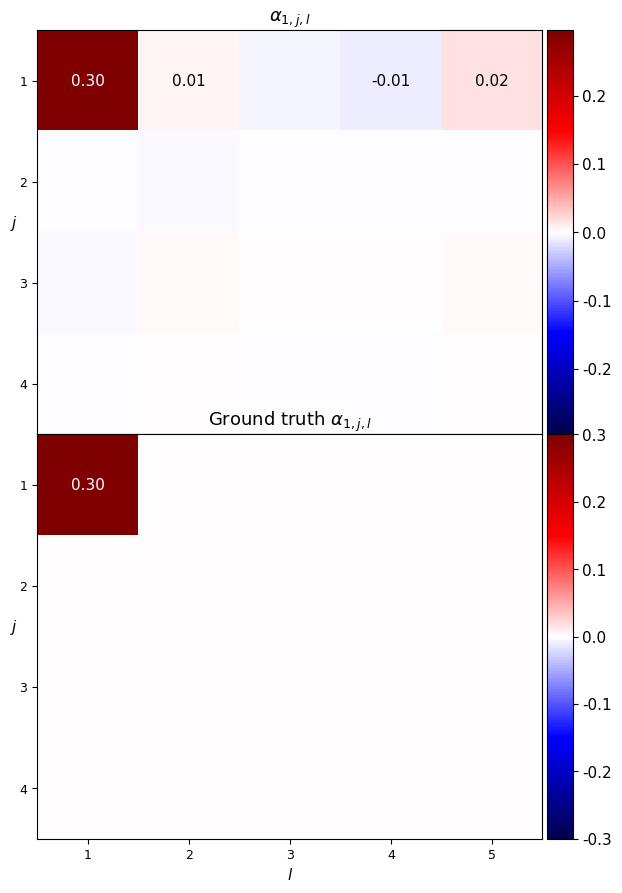

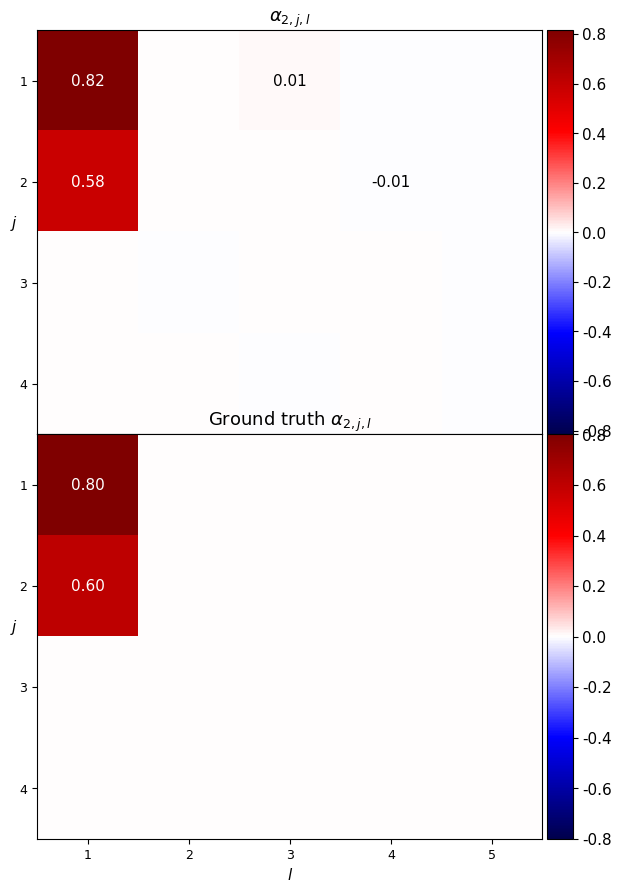

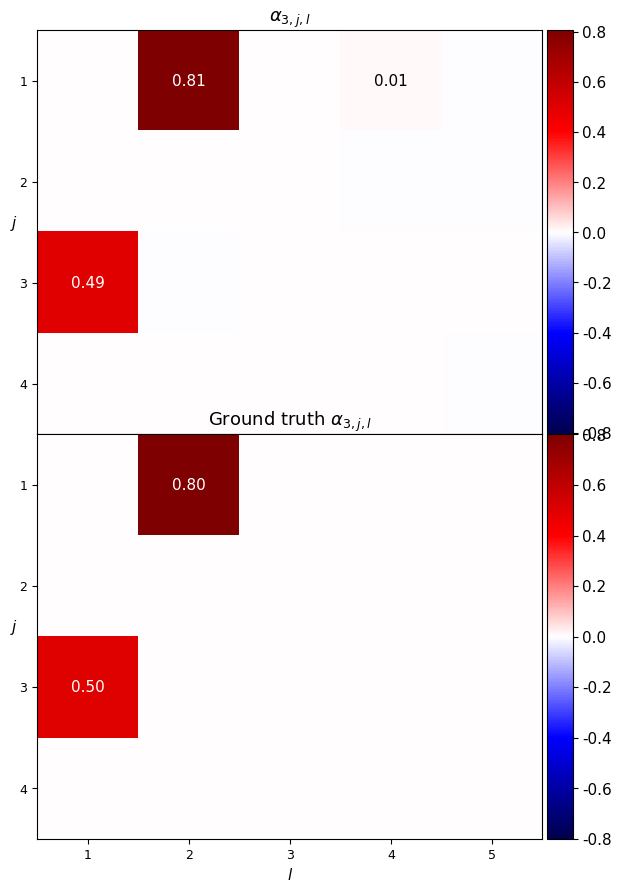

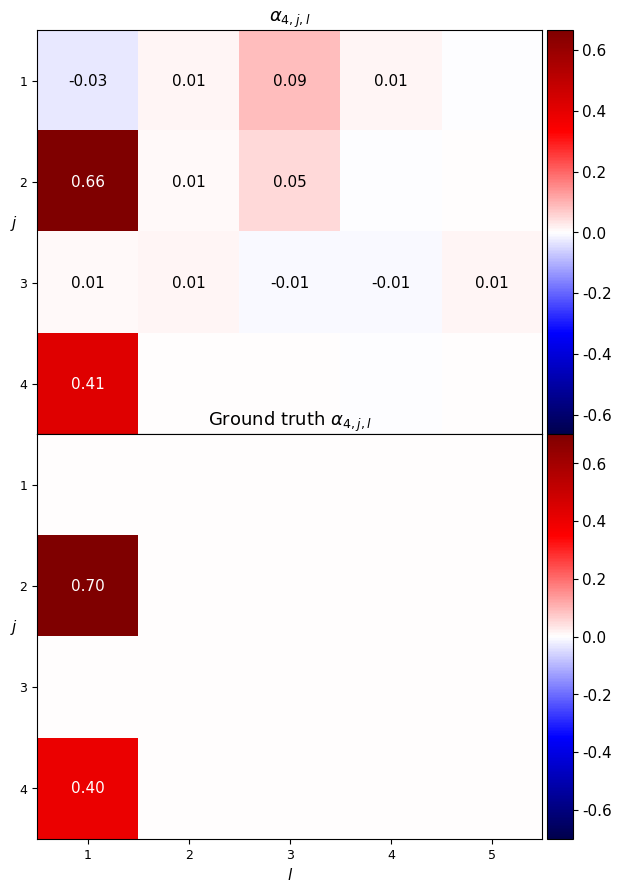

In [ ]:
plot_alphas(stats['alpha'][1]['mean'],ground_truth_alpha, figsize=(8, 7), font_size=11, space=0.0)

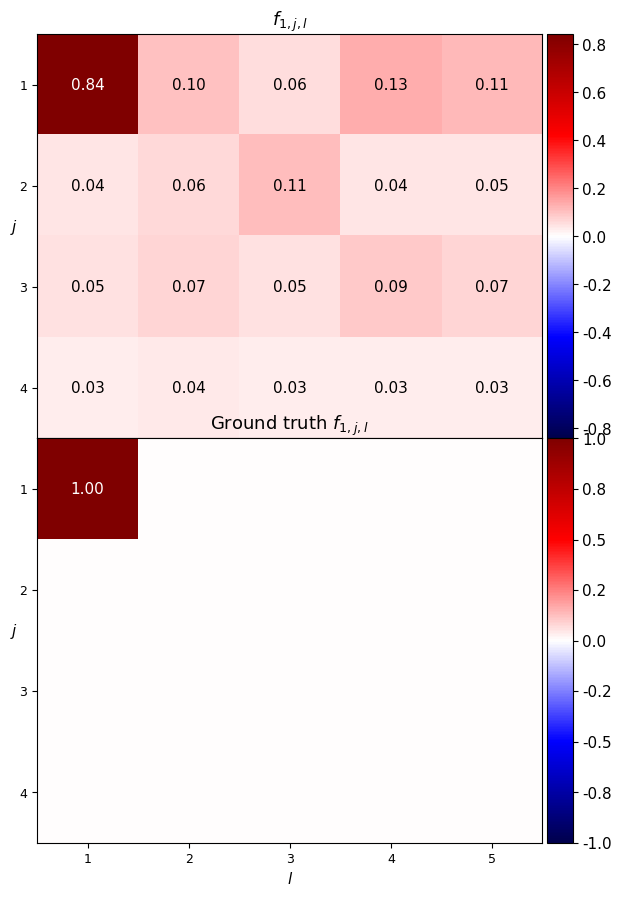

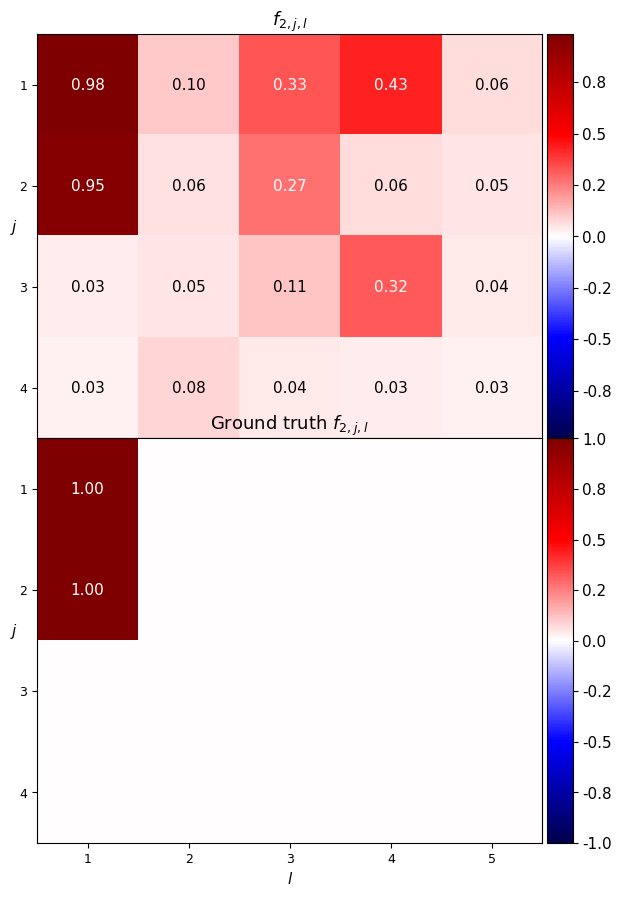

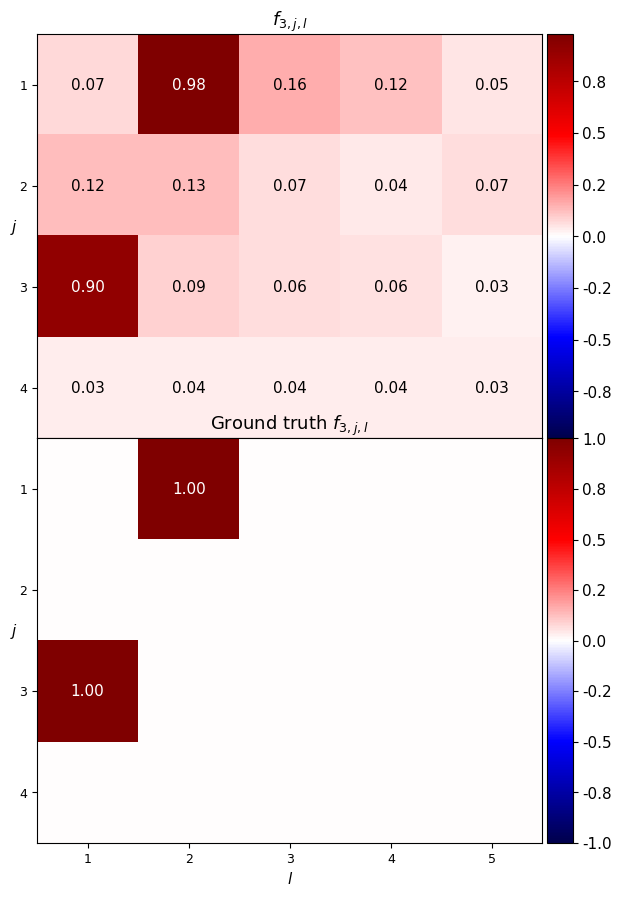

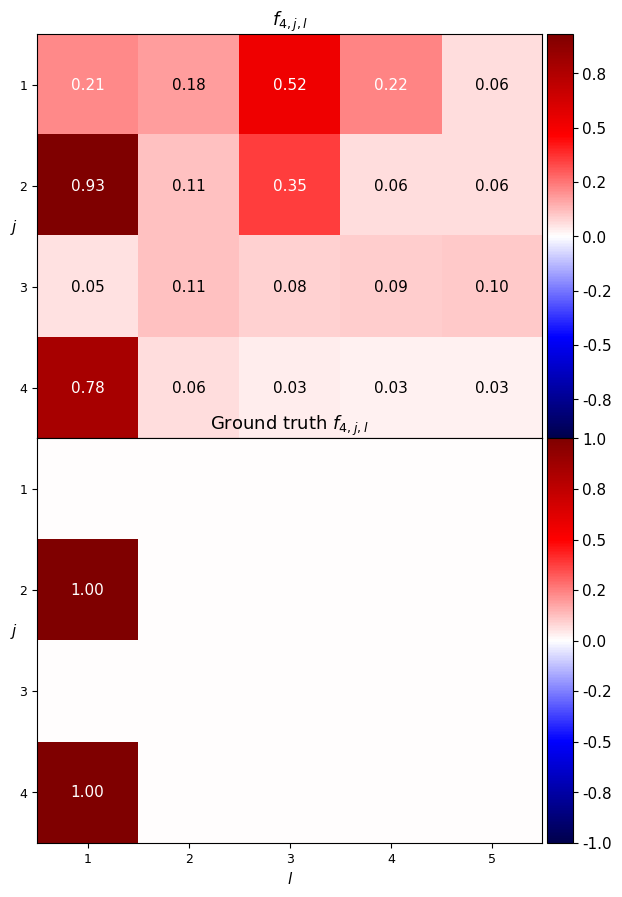

In [16]:
plot_alphas(stats['f'][1]['mean'],alpha_mask, figsize=(8, 7), title=r'f', font_size=11, space=0.0)

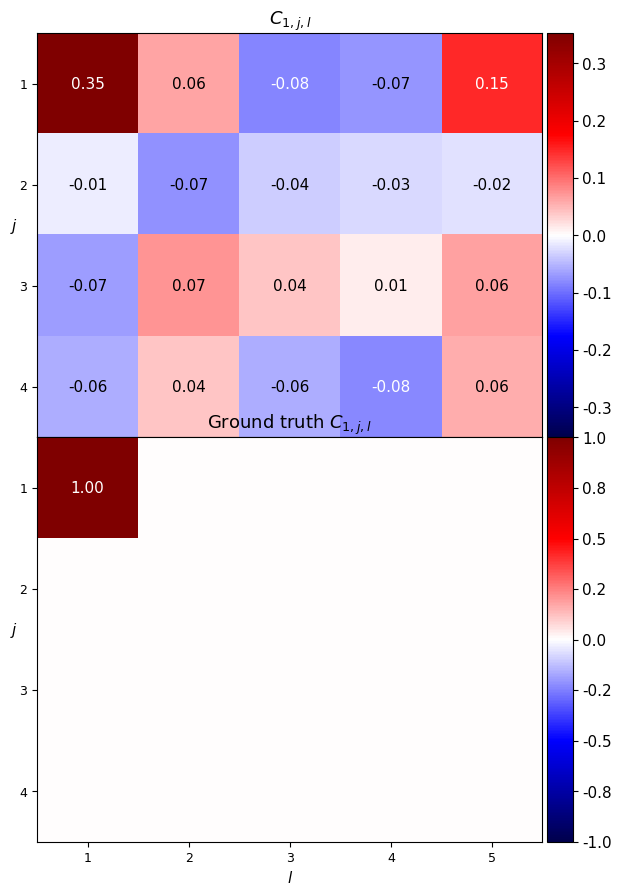

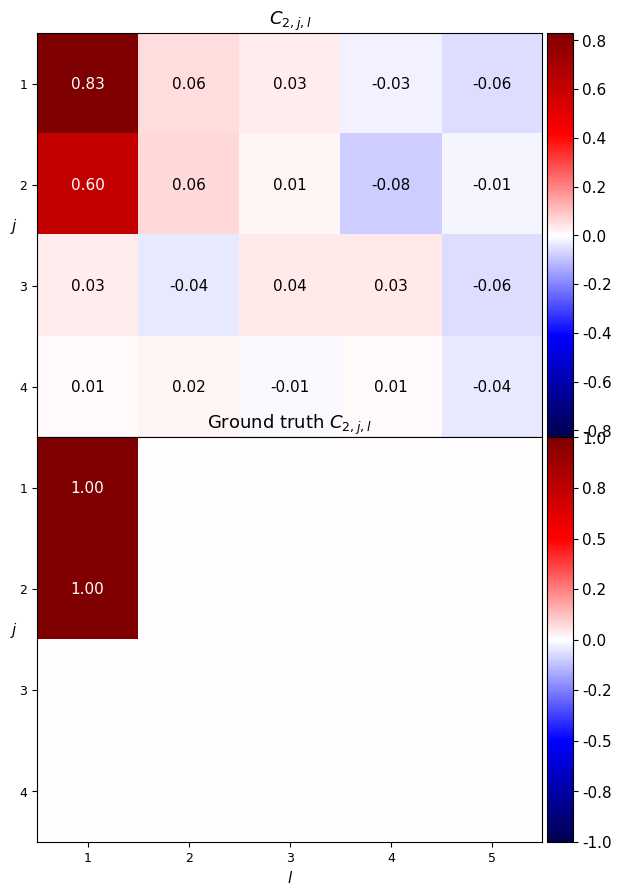

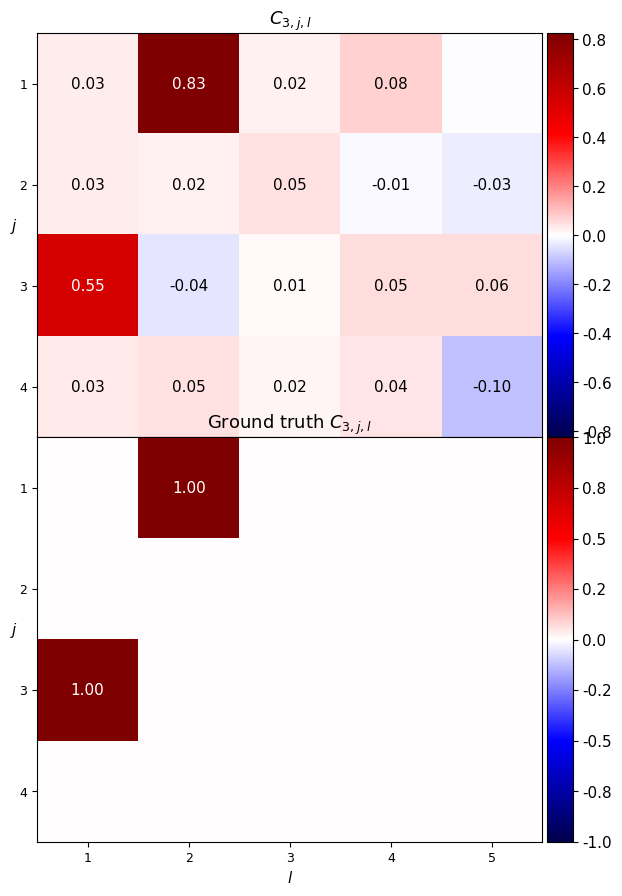

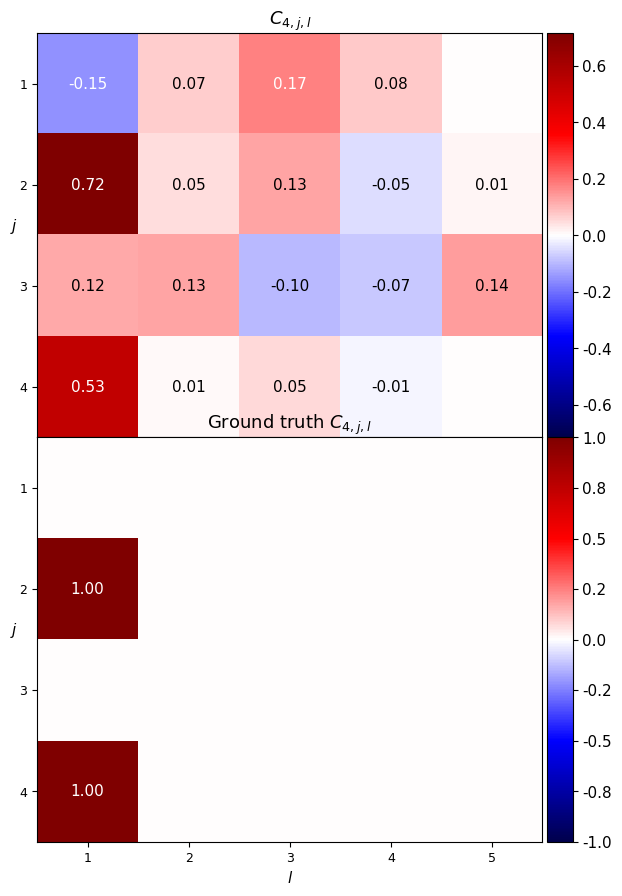

In [17]:
plot_alphas(stats['c'][1]['mean'],alpha_mask, figsize=(8, 7), title=r'C', font_size=11, space=0.0)

# Sintetic generator analysis:

In [42]:
from statsmodels.tsa.seasonal import STL

A_current = A[1]
P_current = P[0]
N_RUNS_SYNTHETIC = 5
ALPHA_THRESHOLD = 0.04

# rho_U_current is defined in the parameter cell and is also used in ground_truth_alpha.
time_series = time_series_hidden_trend(
    mean=mean,
    ts_length=ts_length,
    A=A_current,
    P=P_current,
    rho_U=rho_U_current,
    sigma_U=sigma_U,
    sigma_X=sigma_X,
    sigma_Y=sigma_Y,
    sigma_Z=sigma_Z,
    burn_in=burn_in,
    seed=seed,
)

time_series_observed_U = time_series          # U, X, Y, Z
time_series_hidden_U = time_series[1:, :]    # X, Y, Z

time_series_hidden_U_without_seasonal = torch.zeros_like(time_series_hidden_U) # X, Y, Z
seasonal_components = torch.zeros_like(time_series_hidden_U) 

for series_idx in range(time_series_hidden_U.shape[0]):
    series = time_series_hidden_U[series_idx].detach().cpu().numpy()
    stl_result = STL(series, period=P_current).fit()

    seasonal = stl_result.seasonal
    series_without_seasonal = series - seasonal

    seasonal_components[series_idx] = torch.tensor(seasonal, dtype=torch.float32)
    time_series_hidden_U_without_seasonal[series_idx] = torch.tensor(series_without_seasonal, dtype=torch.float32)

In [43]:
from statsmodels.tsa.stattools import adfuller

names = ["X", "Y", "Z"]

for i, name in enumerate(names):
    series = time_series_hidden_U[i].detach().cpu().numpy()
    p_value = adfuller(series)[1]

    print(f"{name}: p-value = {p_value:.4g}, stationary = {p_value < 0.05}")

X: p-value = 0, stationary = True
Y: p-value = 0, stationary = True
Z: p-value = 0, stationary = True


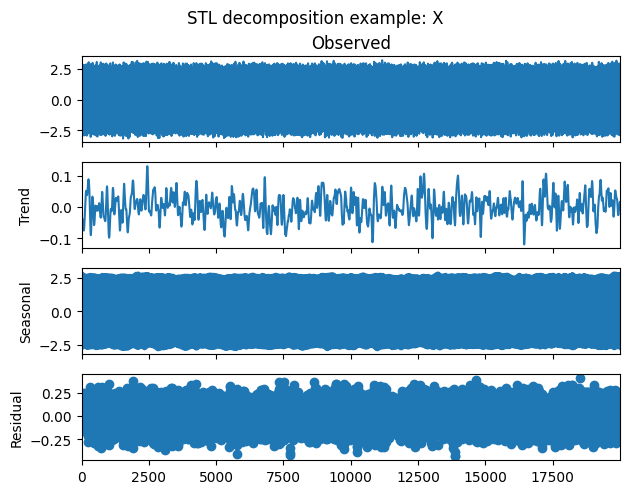

In [44]:
# STL example for X. The seasonal component is what we remove in the no-seasonal case.
stl_example = STL(time_series_hidden_U[0].detach().cpu().numpy(), period=P_current).fit()
stl_example.plot()
plt.suptitle("STL decomposition example: X", y=1.02)
plt.show()

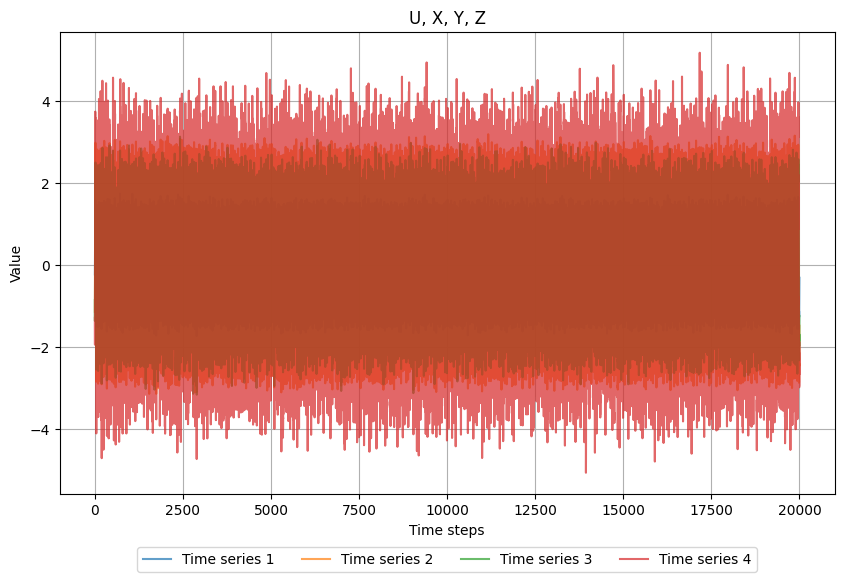

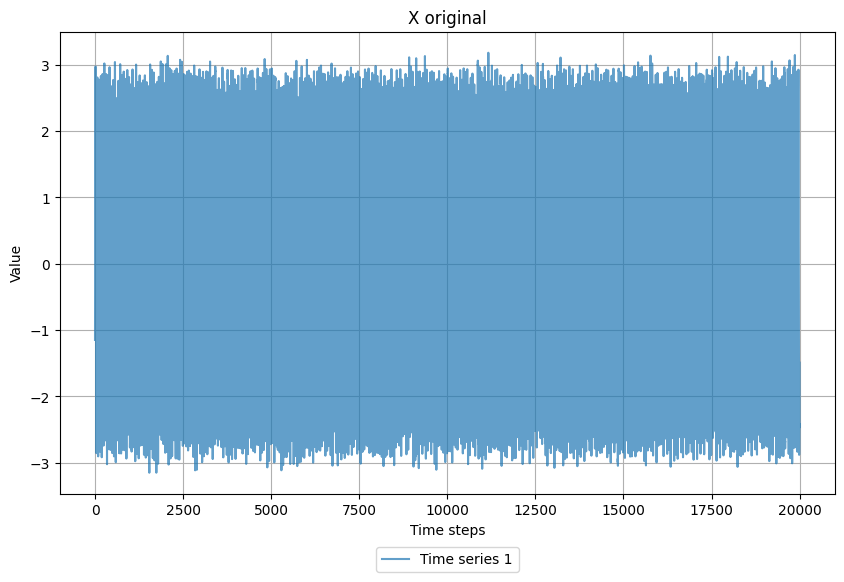

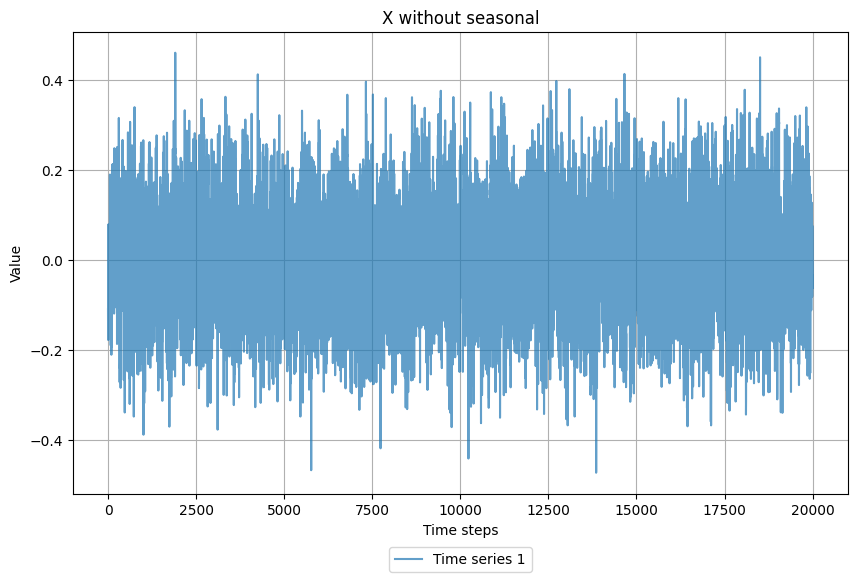

In [45]:
plot_ts(time_series_observed_U, dataset_name="U, X, Y, Z", alpha=0.7)

# plot_ts(time_series_observed_U[:1, :], dataset_name="U", alpha=1)
plot_ts(time_series_observed_U[1:2, :], dataset_name="X original", alpha=0.7)
# plot_ts(time_series_observed_U[2:3, :], dataset_name="Y", alpha=1)
# plot_ts(time_series_observed_U[3:4, :], dataset_name="Z", alpha=1)

plot_ts(time_series_hidden_U_without_seasonal[0:1, :], dataset_name="X without seasonal", alpha=0.7,)

In [46]:
train_config = {
    "verbose": False,
    "device": device,
    "learning_rate": 1e-3,
    "scheduler_patience": 5,
    "early_stopping_modifier": 2,
    "criterion": nn.MSELoss(),
}

synthetic_cases = {
    "observed_U": {
        "time_series": time_series_observed_U,
        "ground_truth_alpha": ground_truth_alpha,
        "ground_truth_bias": ground_truth_bias,
        "alpha_mask": alpha_mask,
        "names": ["U", "X", "Y", "Z"],
    },
    "hidden_U": {
        "time_series": time_series_hidden_U,
        "ground_truth_alpha": ground_truth_alpha_hidden_U,
        "ground_truth_bias": ground_truth_bias_hidden_U,
        "alpha_mask": alpha_mask_hidden_U,
        "names": ["X", "Y", "Z"],
    },
    "hidden_U_without_seasonal": {
        "time_series": time_series_hidden_U_without_seasonal,
        "ground_truth_alpha": ground_truth_alpha_hidden_U,
        "ground_truth_bias": ground_truth_bias_hidden_U,
        "alpha_mask": alpha_mask_hidden_U,
        "names": ["X", "Y", "Z"],
    },
}

In [47]:
for case_name, case in synthetic_cases.items():
    print("=" * 80)
    print(f"Training case: {case_name}")

    case["results"] = collect_multiple_runs(
        n_runs=N_RUNS_SYNTHETIC,
        time_series=case["time_series"],
        window_size=window_length_gp,
        temperature=1.0,
        order=[1, 1],
        config=train_config,
    )

    case["stats"] = calculate_multiple_run_statistics(case["results"])

Training case: observed_U
Training Configuration:
  verbose: False
  device: cuda:0
  learning_rate: 0.001
  scheduler_patience: 5
  early_stopping_modifier: 2
  criterion: MSELoss()
Starting Run 1/5
Run 1 completed. Test Loss: 7.579317e-02
Starting Run 2/5
Run 2 completed. Test Loss: 7.577387e-02
Starting Run 3/5
Run 3 completed. Test Loss: 7.587182e-02
Starting Run 4/5
Run 4 completed. Test Loss: 7.558749e-02
Starting Run 5/5
Run 5 completed. Test Loss: 7.571668e-02
Time taken for Run 2: 73.96 seconds
Training case: hidden_U
Training Configuration:
  verbose: False
  device: cuda:0
  learning_rate: 0.001
  scheduler_patience: 5
  early_stopping_modifier: 2
  criterion: MSELoss()
Starting Run 1/5
Run 1 completed. Test Loss: 1.012852e-01
Starting Run 2/5
Run 2 completed. Test Loss: 1.009420e-01
Starting Run 3/5
Run 3 completed. Test Loss: 1.006153e-01
Starting Run 4/5
Run 4 completed. Test Loss: 1.006215e-01
Starting Run 5/5
Run 5 completed. Test Loss: 1.006145e-01
Time taken for Run 2

In [60]:
summary_rows = []

for case_name, case in synthetic_cases.items():
    results_case = case["results"]
    stats_case = case["stats"]
    gt_alpha = case["ground_truth_alpha"]
    names = case["names"]

    mse_values = np.array([
        results_case[run_key]["test_loss"]
        for run_key in results_case
        if run_key.startswith("run_")
    ])
    rmse_values = np.sqrt(mse_values)

    buffer = io.StringIO()
    with redirect_stdout(buffer):
        print_significant_alpha(stats_case["alpha"][1]["mean"], stats_case["alpha"][1]["std"], gt_alpha, threshold=ALPHA_THRESHOLD,)

    alpha_printout = buffer.getvalue()
    lines = alpha_printout.strip().splitlines()

    n_found = sum("alpha_" in line and "Not in result" not in line for line in lines)
    n_false_positive = sum("Not in ground truth" in line for line in lines)
    n_missed = sum("Not in result" in line for line in lines)
    n_true_positive = n_found - n_false_positive

    lag_table = lag_accuracy_table(stats_case, gt_alpha, alpha_key=1, names=names)
    lag_table["correct_sign"] = (np.sign(lag_table["estimated_alpha_true_lag"]) == np.sign(lag_table["ground_truth_alpha"]))

    alpha_est = np.flip(stats_case["alpha"][1]["mean"], axis=2).flatten()
    alpha_gt = gt_alpha.detach().cpu().numpy().flatten()
    correlation = np.corrcoef(alpha_est, alpha_gt)[0, 1]

    case["alpha_printout"] = alpha_printout
    case["lag_table"] = lag_table

    summary_rows.append({
        "case": case_name,
        "mean_MSE": mse_values.mean(),
        "std_MSE": mse_values.std(),
        "mean_RMSE": rmse_values.mean(),
        "std_RMSE": rmse_values.std(),
        "found_stable_links": n_found,
        "true_positives": n_true_positive,
        "false_positives": n_false_positive,
        "missed_true_links": n_missed,
        "lag_accuracy": lag_table["correct_lag"].mean(),
        "sign_accuracy": lag_table["correct_sign"].mean(),
        "alpha_correlation": correlation,
    })

summary_table = pd.DataFrame(summary_rows)
display(summary_table)

,case,mean_MSE,std_MSE,mean_RMSE,std_RMSE,found_stable_links,true_positives,false_positives,missed_true_links,lag_accuracy,sign_accuracy,alpha_correlation
0,observed_U,0.075749,0.000095,0.275225,0.000172,18,7,11,0,1.0,1.0,0.922296
1,hidden_U,0.100816,0.000266,0.317515,0.000419,9,4,5,0,1.0,1.0,0.818362
2,hidden_U_without_seasonal,0.066089,0.000132,0.257077,0.000256,9,4,5,0,1.0,1.0,0.798678


In [ ]:
for case_name, case in synthetic_cases.items():
    print("=" * 80)
    print(f"Case: {case_name}")

    print_bias(case["stats"]["alpha_bias"]["mean"], case["stats"]["alpha_bias"]["std"], case["ground_truth_bias"],)

    print(case["alpha_printout"])

    display(case["lag_table"])

    false_positive_table = make_false_positive_table(
        case["stats"],
        case["ground_truth_alpha"],
        case["names"],
        alpha_key=1,
        threshold=ALPHA_THRESHOLD,
    )

    display(false_positive_table)

Case: observed_U
bias_1 = (0.004 ± 0.004), gt_bias_1 = 0.000
bias_2 = (-0.000 ± 0.003), gt_bias_2 = 0.000
bias_3 = (-0.002 ± 0.003), gt_bias_3 = 0.000
bias_4 = (-0.010 ± 0.006), gt_bias_4 = 0.000
alpha_111 = (0.65 ± 0.01), gt_alpha_111 = 0.30
alpha_112 = (0.23 ± 0.02) Not in ground truth
alpha_113 = (0.12 ± 0.03) Not in ground truth
alpha_114 = (0.064 ± 0.005) Not in ground truth
alpha_115 = (0.08 ± 0.01) Not in ground truth
alpha_125 = (-0.131 ± 0.008) Not in ground truth
alpha_135 = (-0.041 ± 0.003) Not in ground truth
alpha_211 = (0.79 ± 0.01), gt_alpha_211 = 0.80
alpha_212 = (0.09 ± 0.03) Not in ground truth
alpha_221 = (0.48 ± 0.04), gt_alpha_221 = 0.60
alpha_222 = (0.05 ± 0.02) Not in ground truth
alpha_312 = (0.75 ± 0.02), gt_alpha_312 = 0.80
alpha_331 = (0.4988 ± 0.0010), gt_alpha_331 = 0.5000
alpha_412 = (0.14 ± 0.05) Not in ground truth
alpha_413 = (0.15 ± 0.02) Not in ground truth
alpha_414 = (0.06 ± 0.03) Not in ground truth
alpha_421 = (0.42 ± 0.05), gt_alpha_421 = 0.70
al

,source,target,true_lag,estimated_best_lag,correct_lag,ground_truth_alpha,estimated_alpha_true_lag,estimated_alpha_best_lag,correct_sign
0,U,U,1,1,True,0.3,0.651135,0.651135,True
1,U,X,1,1,True,0.8,0.794756,0.794756,True
2,X,X,1,1,True,0.6,0.482142,0.482142,True
3,U,Y,2,2,True,0.8,0.746064,0.746064,True
4,Y,Y,1,1,True,0.5,0.498778,0.498778,True
5,X,Z,1,1,True,0.7,0.422060,0.422060,True
6,Z,Z,1,1,True,0.4,0.412362,0.412362,True


,source,target,lag,mean_alpha,std_alpha
0,U,U,2,0.226666,0.023862
2,U,Z,3,0.148247,0.024198
3,X,U,5,-0.130935,0.007946
1,U,X,2,0.092519,0.032818
4,X,X,2,0.050449,0.020504
5,Y,U,5,-0.041306,0.002755


Case: hidden_U
bias_1 = (-0.01 ± 0.02), gt_bias_1 = 0.00
bias_2 = (-0.003 ± 0.004), gt_bias_2 = 0.000
bias_3 = (-0.007 ± 0.003), gt_bias_3 = 0.000
alpha_111 = (1.165 ± 0.007), gt_alpha_111 = 0.600
alpha_115 = (-0.16 ± 0.01) Not in ground truth
alpha_125 = (-0.046 ± 0.003) Not in ground truth
alpha_211 = (0.70 ± 0.03) Not in ground truth
alpha_212 = (-0.16 ± 0.06) Not in ground truth
alpha_221 = (0.492 ± 0.008), gt_alpha_221 = 0.500
alpha_311 = (0.60 ± 0.02), gt_alpha_311 = 0.70
alpha_312 = (0.07 ± 0.03) Not in ground truth
alpha_331 = (0.419 ± 0.006), gt_alpha_331 = 0.400



,source,target,true_lag,estimated_best_lag,correct_lag,ground_truth_alpha,estimated_alpha_true_lag,estimated_alpha_best_lag,correct_sign
0,X,X,1,1,True,0.6,1.164852,1.164852,True
1,Y,Y,1,1,True,0.5,0.491543,0.491543,True
2,X,Z,1,1,True,0.7,0.600331,0.600331,True
3,Z,Z,1,1,True,0.4,0.418657,0.418657,True


,source,target,lag,mean_alpha,std_alpha
1,X,Y,1,0.698362,0.028306
0,X,X,5,-0.158035,0.013736
2,X,Z,2,0.071028,0.029257
3,Y,X,5,-0.046047,0.003219


Case: hidden_U_without_seasonal
bias_1 = (0.000 ± 0.001), gt_bias_1 = 0.000
bias_2 = (0.0034 ± 0.0009), gt_bias_2 = 0.0000
bias_3 = (-0.006 ± 0.003), gt_bias_3 = 0.000
alpha_111 = (0.83 ± 0.03), gt_alpha_111 = 0.60
alpha_112 = (-0.113 ± 0.009) Not in ground truth
alpha_211 = (0.73 ± 0.06) Not in ground truth
alpha_212 = (-0.36 ± 0.04) Not in ground truth
alpha_221 = (0.49 ± 0.02), gt_alpha_221 = 0.50
alpha_311 = (0.62 ± 0.05), gt_alpha_311 = 0.70
alpha_323 = (-0.04 ± 0.01) Not in ground truth
alpha_324 = (-0.050 ± 0.004) Not in ground truth
alpha_331 = (0.44 ± 0.02), gt_alpha_331 = 0.40



,source,target,true_lag,estimated_best_lag,correct_lag,ground_truth_alpha,estimated_alpha_true_lag,estimated_alpha_best_lag,correct_sign
0,X,X,1,1,True,0.6,0.830247,0.830247,True
1,Y,Y,1,1,True,0.5,0.492618,0.492618,True
2,X,Z,1,1,True,0.7,0.615512,0.615512,True
3,Z,Z,1,1,True,0.4,0.442175,0.442175,True


,source,target,lag,mean_alpha,std_alpha
1,X,Y,1,0.727520,0.060780
0,X,X,2,-0.113439,0.008550
2,Y,Z,4,-0.050008,0.003914


In [49]:
for case_name, case in synthetic_cases.items():
    print("=" * 80)
    print(f"Case: {case_name}")
    print_bias(case["stats"]["alpha_bias"]["mean"], case["stats"]["alpha_bias"]["std"], case["ground_truth_bias"],)

    print(case["alpha_printout"])
    display(case["lag_table"])

Case: observed_U
bias_1 = (0.004 ± 0.004), gt_bias_1 = 0.000
bias_2 = (-0.000 ± 0.003), gt_bias_2 = 0.000
bias_3 = (-0.002 ± 0.003), gt_bias_3 = 0.000
bias_4 = (-0.010 ± 0.006), gt_bias_4 = 0.000
alpha_111 = (0.65 ± 0.01), gt_alpha_111 = 0.30
alpha_112 = (0.23 ± 0.02) Not in ground truth
alpha_113 = (0.12 ± 0.03) Not in ground truth
alpha_114 = (0.064 ± 0.005) Not in ground truth
alpha_115 = (0.08 ± 0.01) Not in ground truth
alpha_125 = (-0.131 ± 0.008) Not in ground truth
alpha_135 = (-0.041 ± 0.003) Not in ground truth
alpha_211 = (0.79 ± 0.01), gt_alpha_211 = 0.80
alpha_212 = (0.09 ± 0.03) Not in ground truth
alpha_221 = (0.48 ± 0.04), gt_alpha_221 = 0.60
alpha_222 = (0.05 ± 0.02) Not in ground truth
alpha_312 = (0.75 ± 0.02), gt_alpha_312 = 0.80
alpha_331 = (0.4988 ± 0.0010), gt_alpha_331 = 0.5000
alpha_412 = (0.14 ± 0.05) Not in ground truth
alpha_413 = (0.15 ± 0.02) Not in ground truth
alpha_414 = (0.06 ± 0.03) Not in ground truth
alpha_421 = (0.42 ± 0.05), gt_alpha_421 = 0.70
al

,source,target,true_lag,estimated_best_lag,correct_lag,ground_truth_alpha,estimated_alpha_true_lag,estimated_alpha_best_lag,correct_sign
0,U,U,1,1,True,0.3,0.651135,0.651135,True
1,U,X,1,1,True,0.8,0.794756,0.794756,True
2,X,X,1,1,True,0.6,0.482142,0.482142,True
3,U,Y,2,2,True,0.8,0.746064,0.746064,True
4,Y,Y,1,1,True,0.5,0.498778,0.498778,True
5,X,Z,1,1,True,0.7,0.422060,0.422060,True
6,Z,Z,1,1,True,0.4,0.412362,0.412362,True


Case: hidden_U
bias_1 = (-0.01 ± 0.02), gt_bias_1 = 0.00
bias_2 = (-0.003 ± 0.004), gt_bias_2 = 0.000
bias_3 = (-0.007 ± 0.003), gt_bias_3 = 0.000
alpha_111 = (1.165 ± 0.007), gt_alpha_111 = 0.600
alpha_115 = (-0.16 ± 0.01) Not in ground truth
alpha_125 = (-0.046 ± 0.003) Not in ground truth
alpha_211 = (0.70 ± 0.03) Not in ground truth
alpha_212 = (-0.16 ± 0.06) Not in ground truth
alpha_221 = (0.492 ± 0.008), gt_alpha_221 = 0.500
alpha_311 = (0.60 ± 0.02), gt_alpha_311 = 0.70
alpha_312 = (0.07 ± 0.03) Not in ground truth
alpha_331 = (0.419 ± 0.006), gt_alpha_331 = 0.400



,source,target,true_lag,estimated_best_lag,correct_lag,ground_truth_alpha,estimated_alpha_true_lag,estimated_alpha_best_lag,correct_sign
0,X,X,1,1,True,0.6,1.164852,1.164852,True
1,Y,Y,1,1,True,0.5,0.491543,0.491543,True
2,X,Z,1,1,True,0.7,0.600331,0.600331,True
3,Z,Z,1,1,True,0.4,0.418657,0.418657,True


Case: hidden_U_without_seasonal
bias_1 = (0.000 ± 0.001), gt_bias_1 = 0.000
bias_2 = (0.0034 ± 0.0009), gt_bias_2 = 0.0000
bias_3 = (-0.006 ± 0.003), gt_bias_3 = 0.000
alpha_111 = (0.83 ± 0.03), gt_alpha_111 = 0.60
alpha_112 = (-0.113 ± 0.009) Not in ground truth
alpha_211 = (0.73 ± 0.06) Not in ground truth
alpha_212 = (-0.36 ± 0.04) Not in ground truth
alpha_221 = (0.49 ± 0.02), gt_alpha_221 = 0.50
alpha_311 = (0.62 ± 0.05), gt_alpha_311 = 0.70
alpha_323 = (-0.04 ± 0.01) Not in ground truth
alpha_324 = (-0.050 ± 0.004) Not in ground truth
alpha_331 = (0.44 ± 0.02), gt_alpha_331 = 0.40



,source,target,true_lag,estimated_best_lag,correct_lag,ground_truth_alpha,estimated_alpha_true_lag,estimated_alpha_best_lag,correct_sign
0,X,X,1,1,True,0.6,0.830247,0.830247,True
1,Y,Y,1,1,True,0.5,0.492618,0.492618,True
2,X,Z,1,1,True,0.7,0.615512,0.615512,True
3,Z,Z,1,1,True,0.4,0.442175,0.442175,True


Alpha heatmaps: observed_U


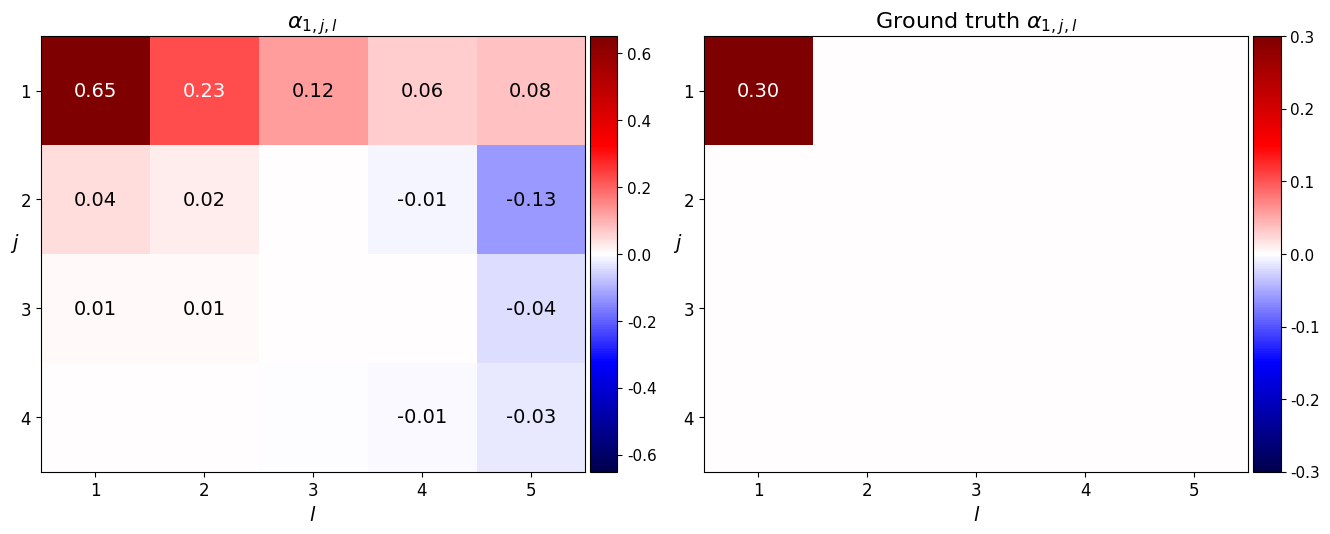

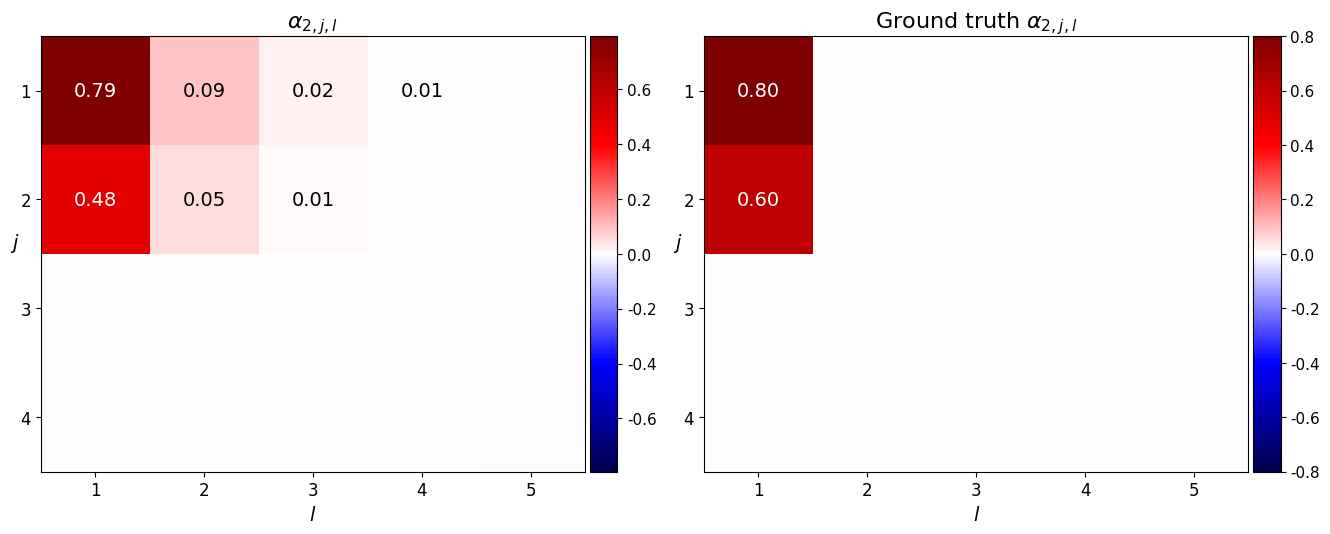

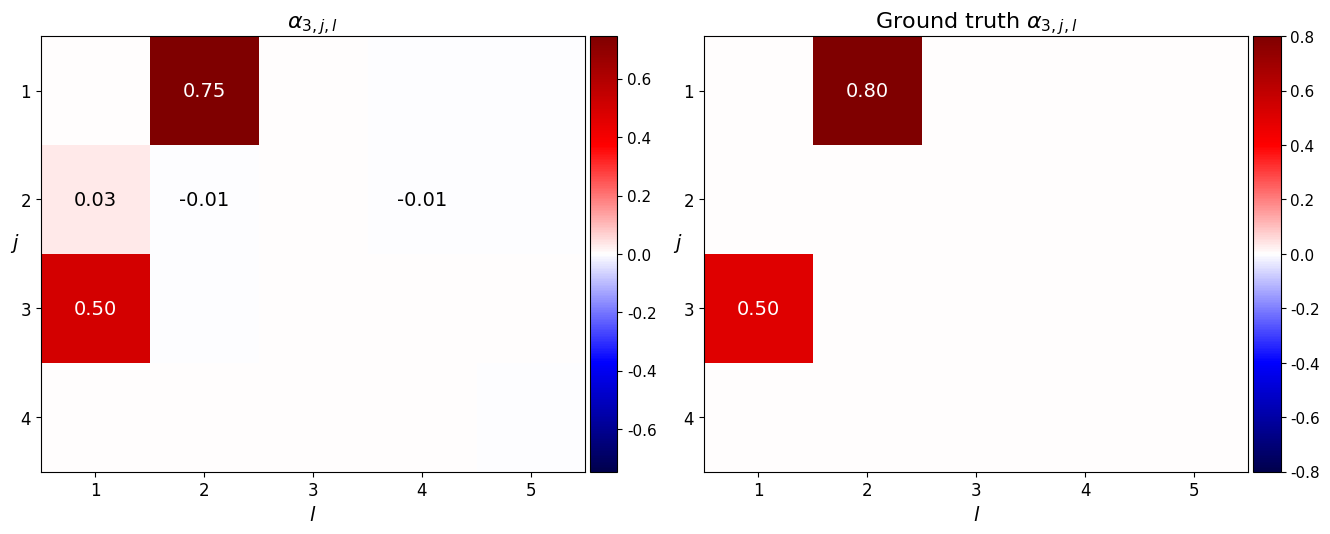

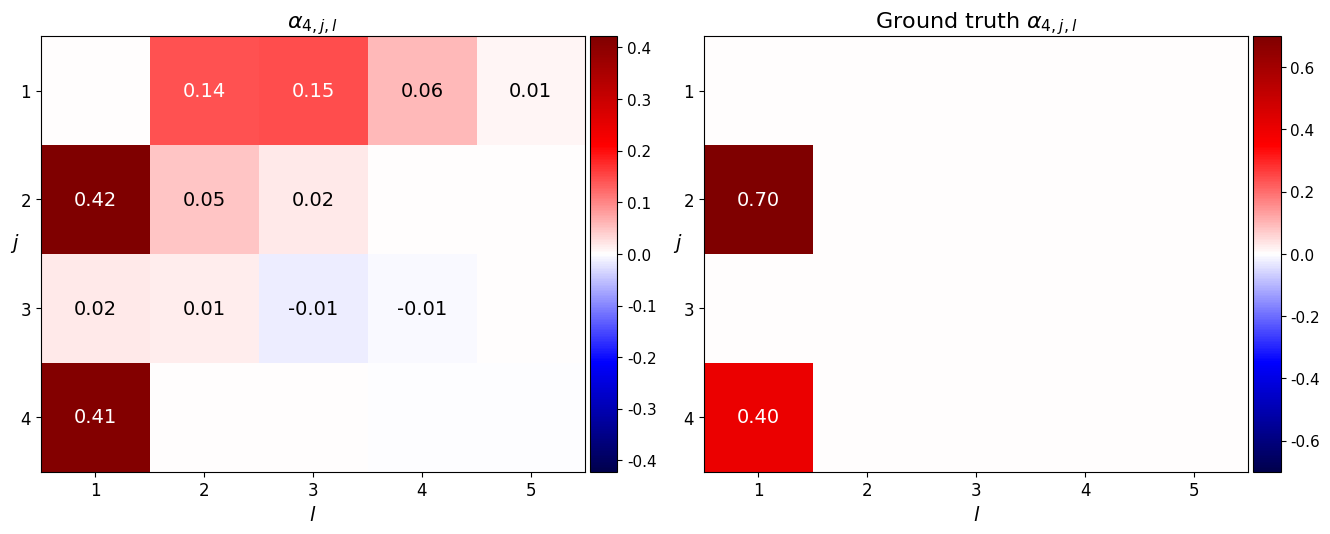

Alpha heatmaps: hidden_U


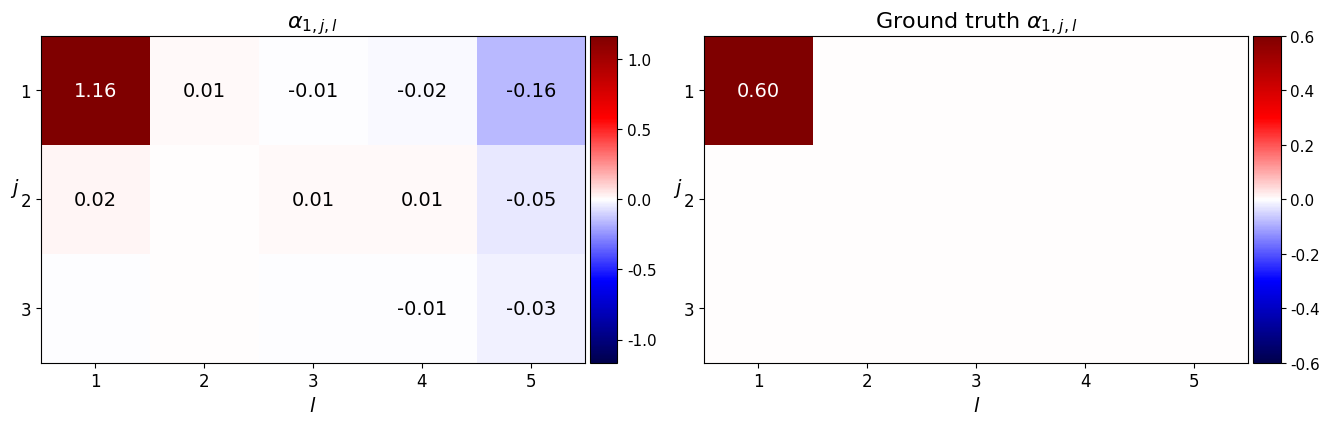

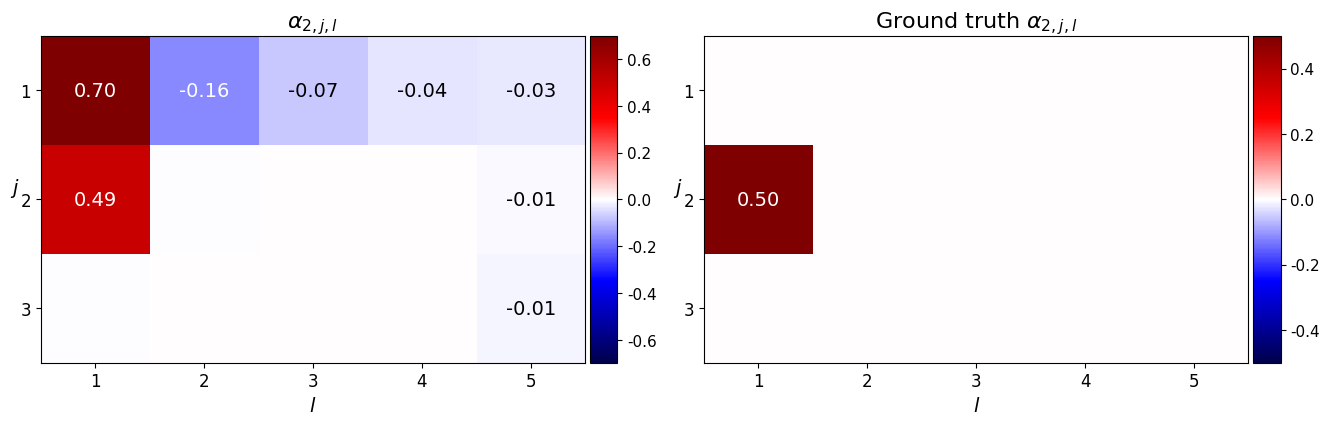

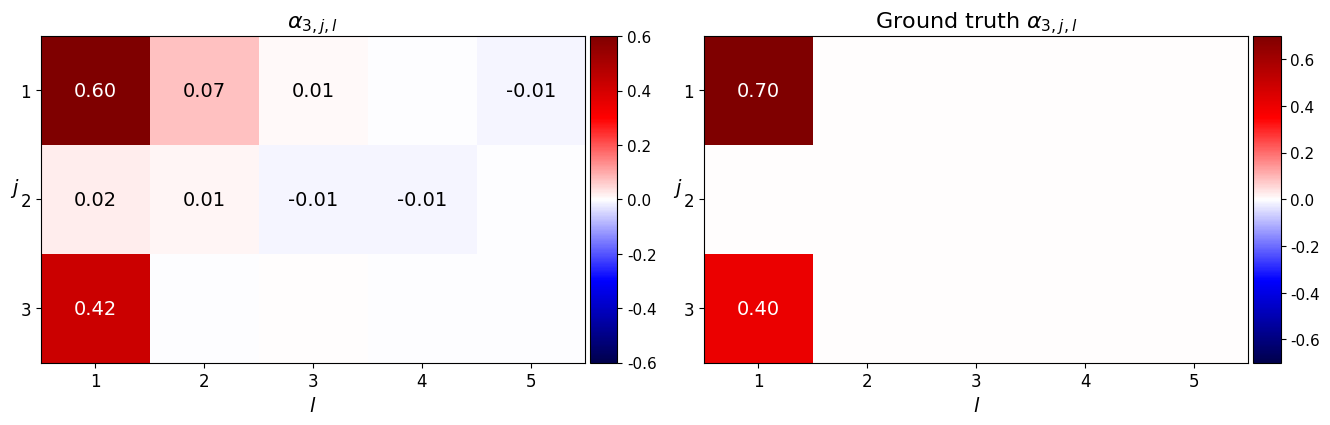

Alpha heatmaps: hidden_U_without_seasonal


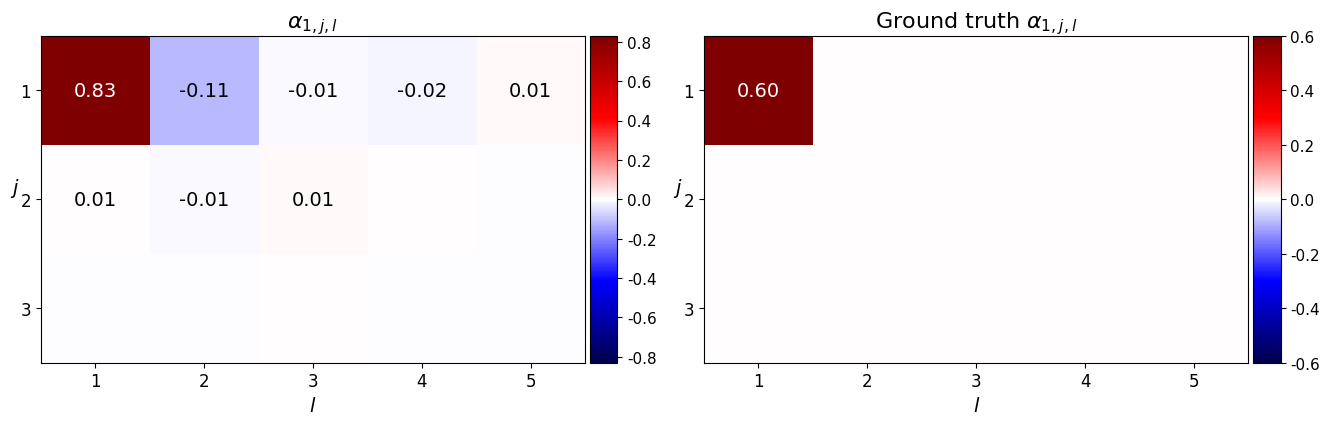

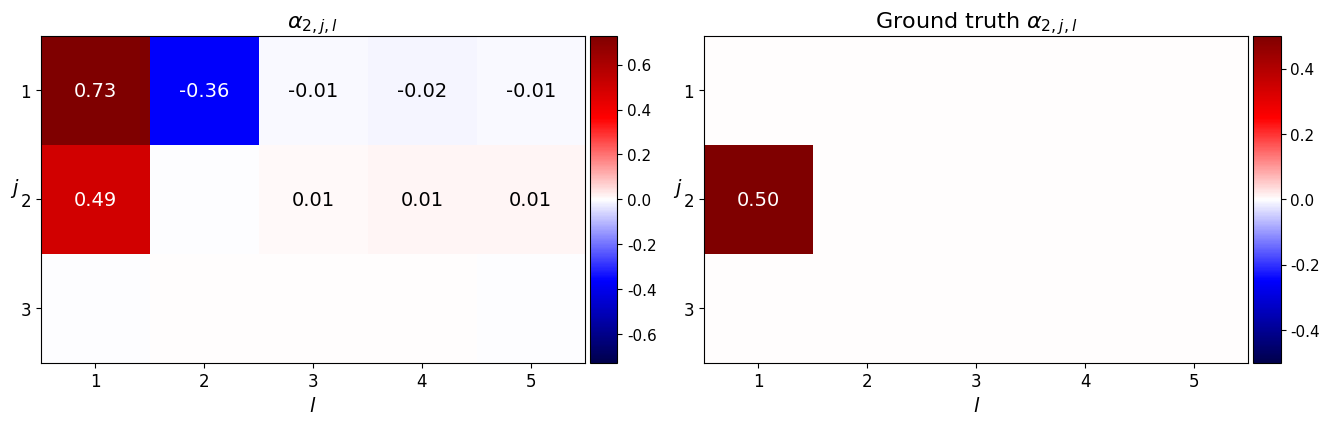

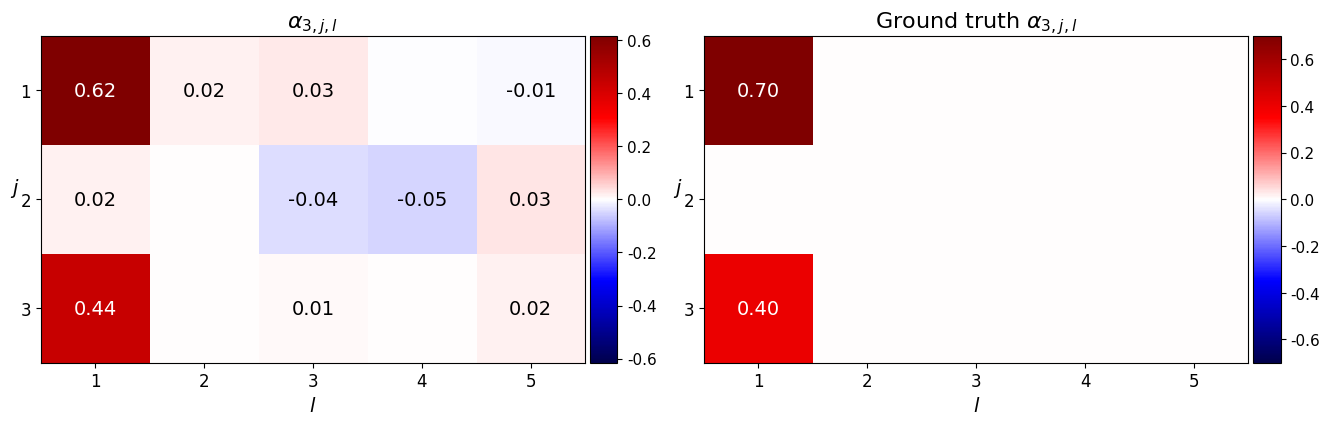

In [56]:
for case_name, case in synthetic_cases.items():
    print("=" * 80)
    print(f"Alpha heatmaps: {case_name}")
    plot_alphas(case["stats"]["alpha"][1]["mean"], case["ground_truth_alpha"], figsize=(8, 7), font_size=14, space=0.15, force_12=True)

Focuser heatmaps: observed_U


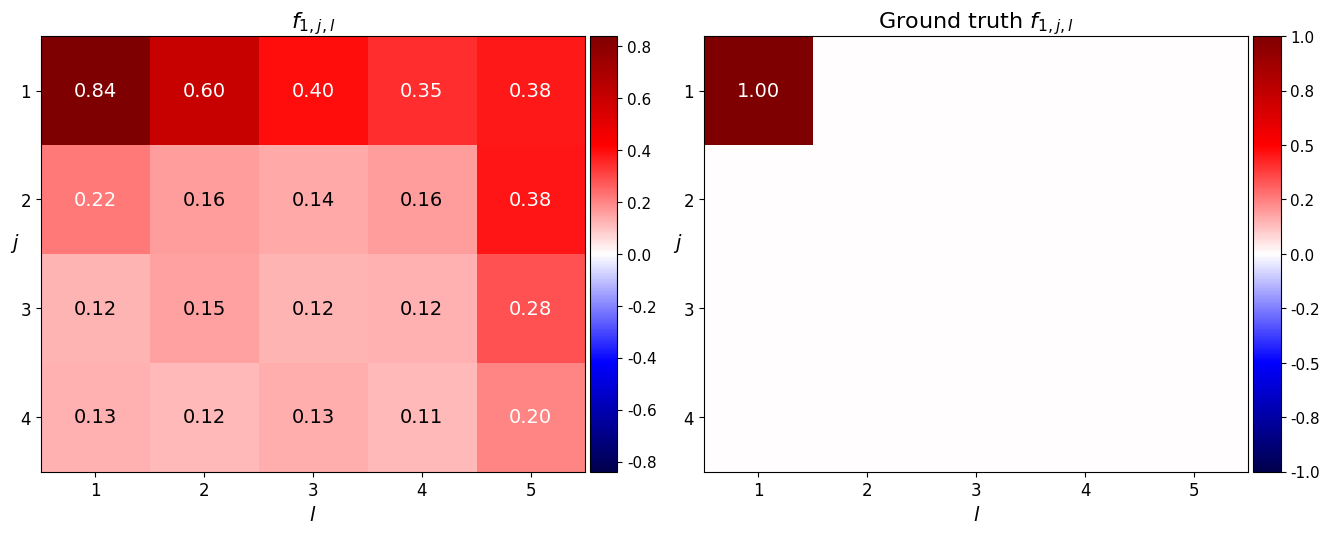

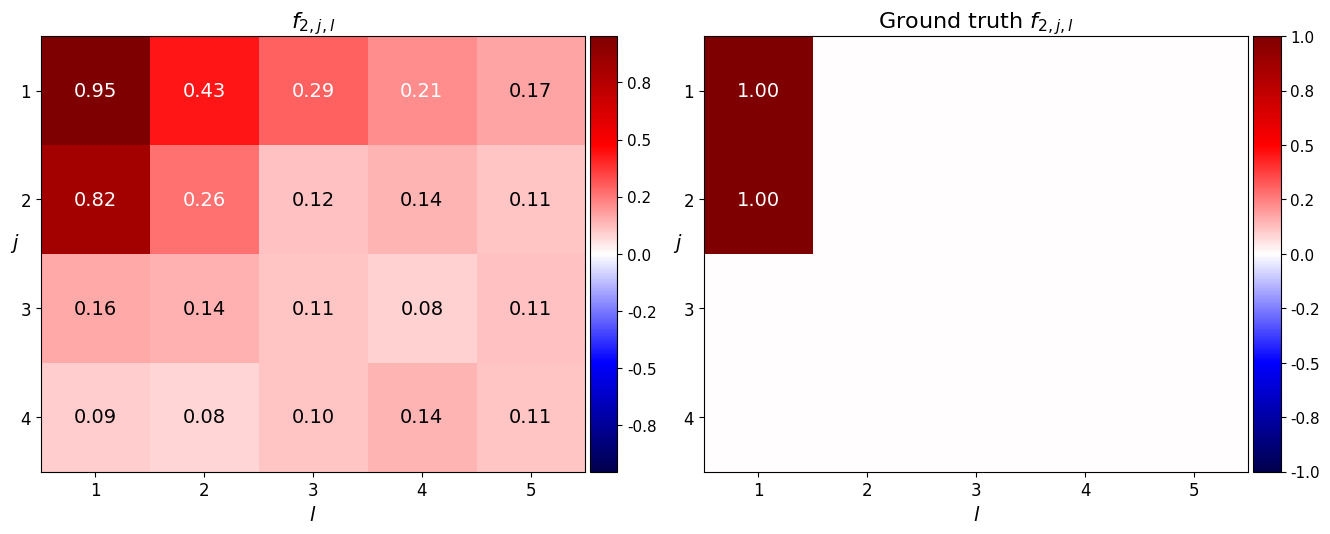

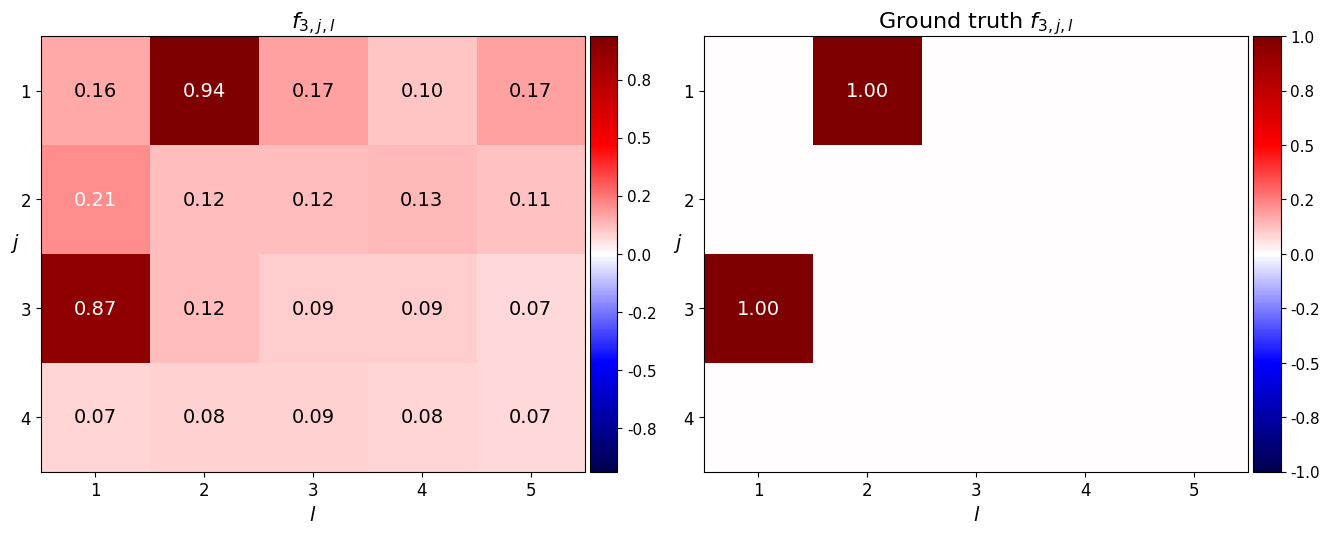

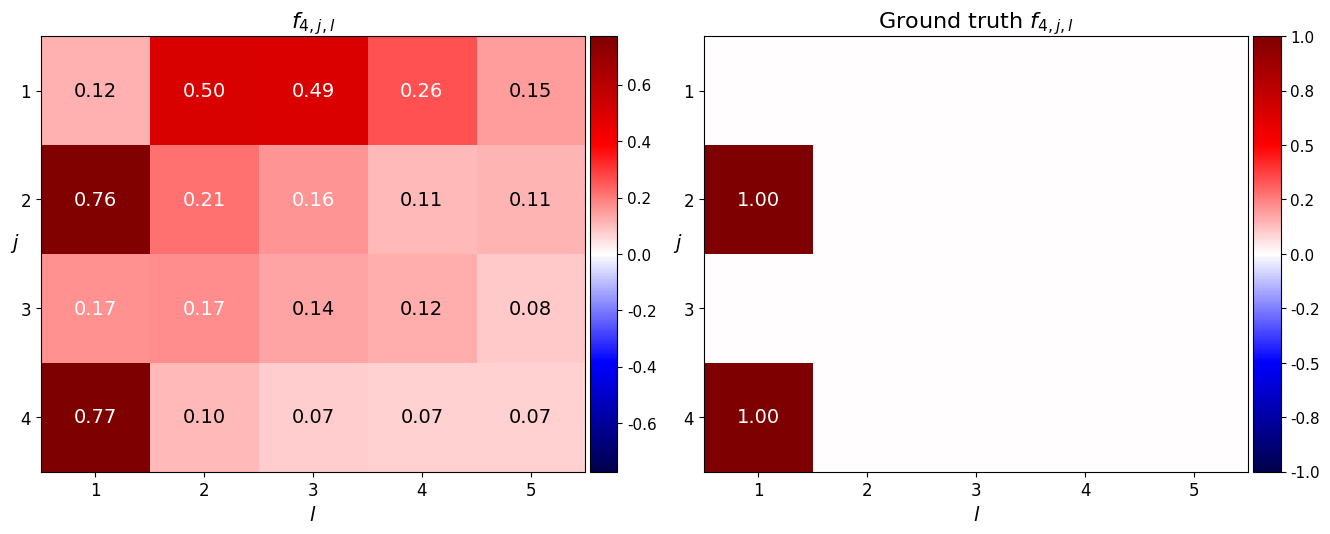

Focuser heatmaps: hidden_U


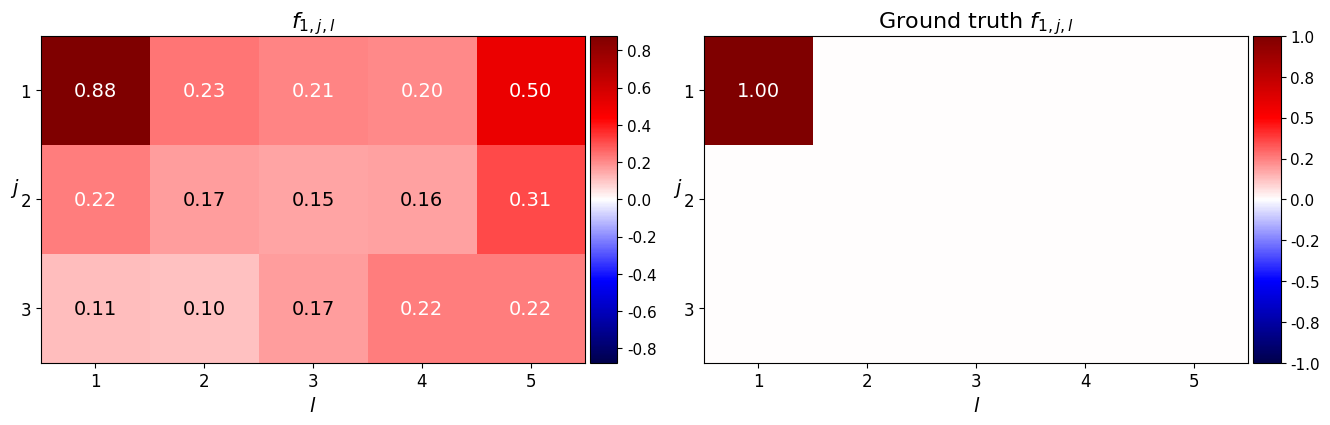

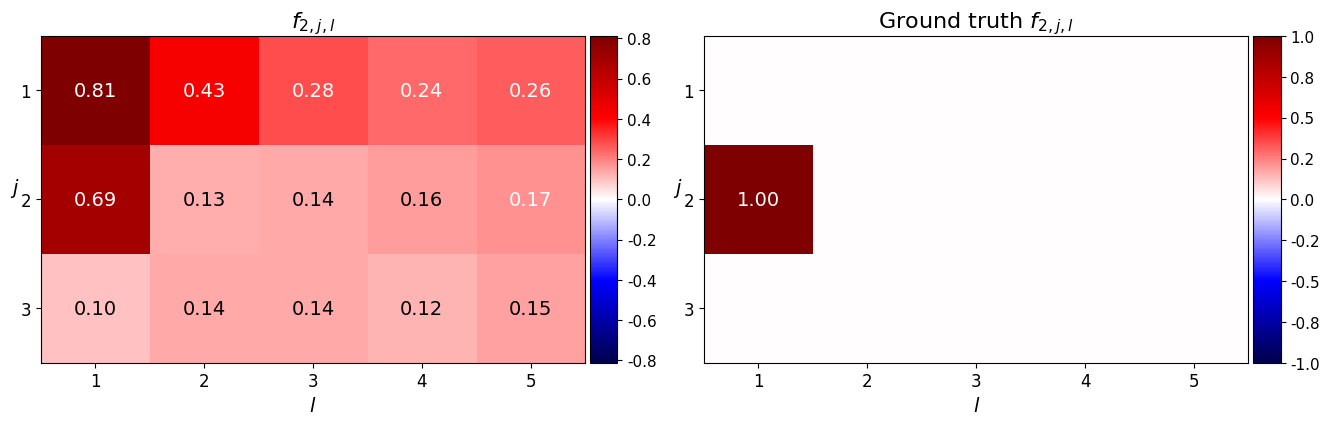

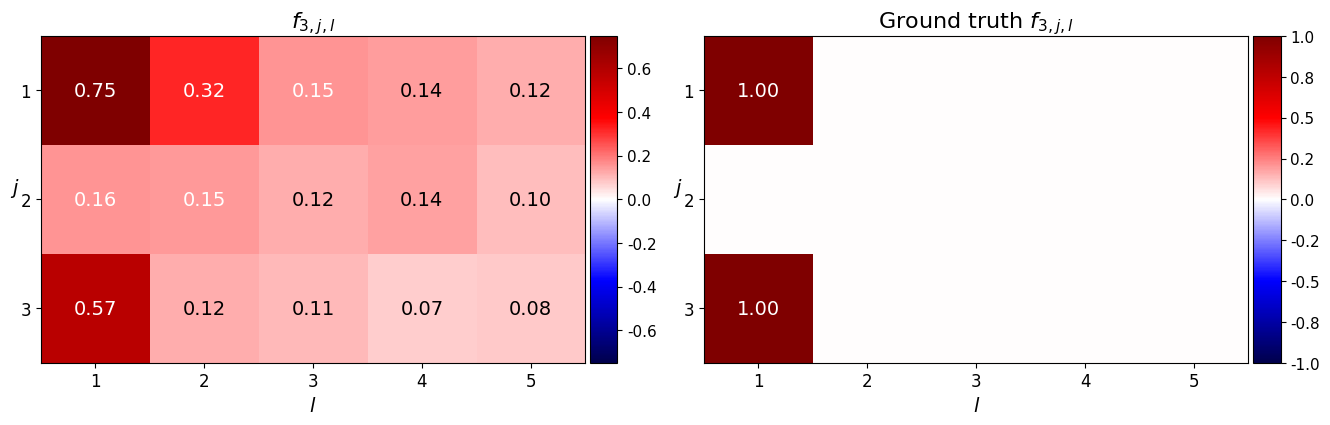

Focuser heatmaps: hidden_U_without_seasonal


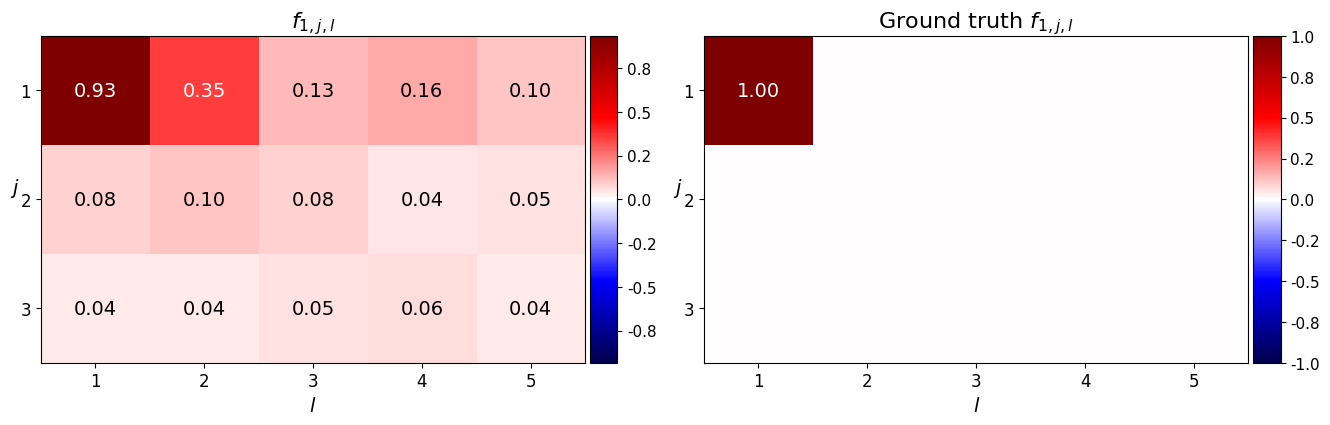

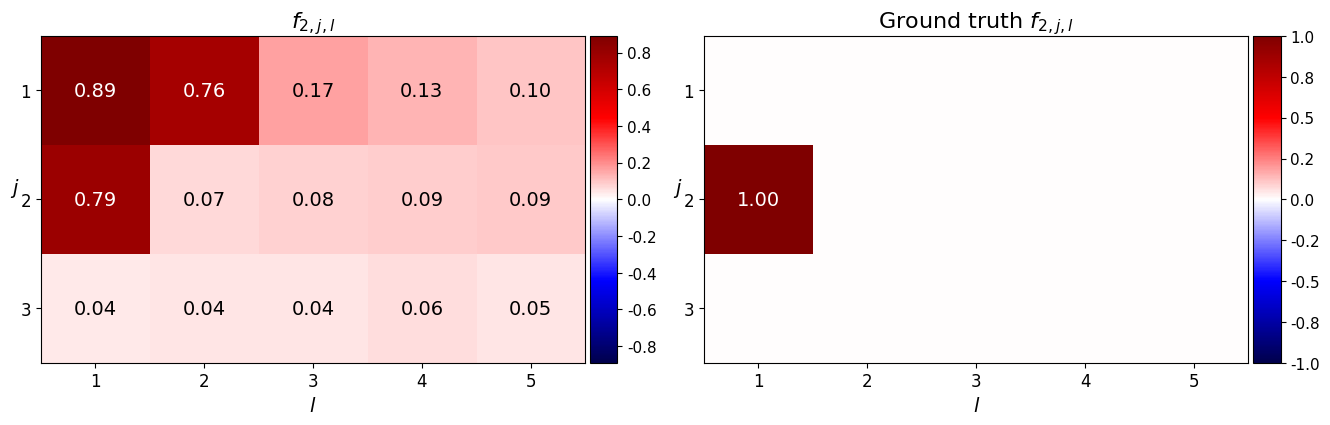

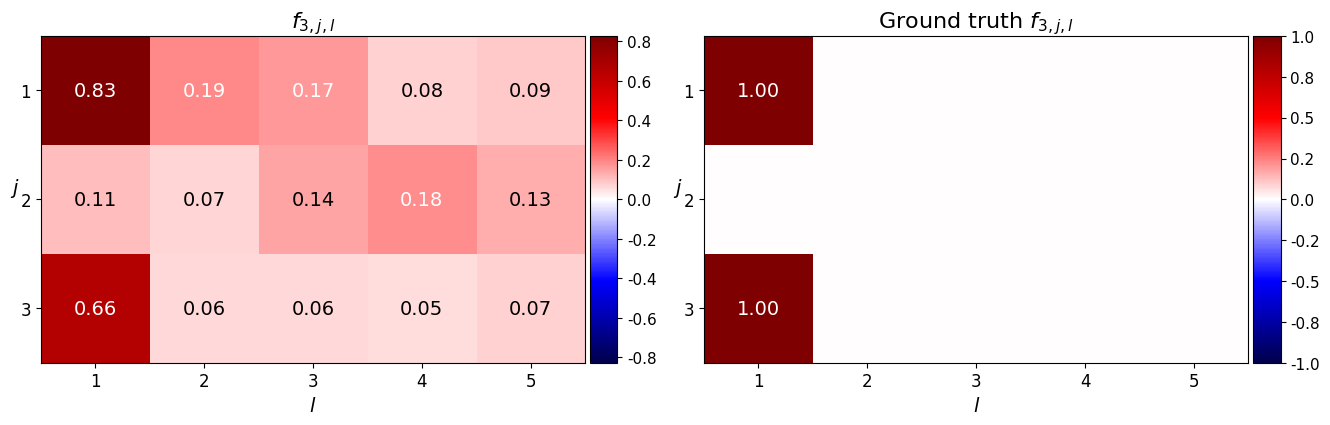

In [57]:
for case_name, case in synthetic_cases.items():
    print("=" * 80)
    print(f"Focuser heatmaps: {case_name}")
    plot_alphas(case["stats"]["f"][1]["mean"], case["alpha_mask"], figsize=(8, 7), title=r"f", font_size=14, space=0.15, force_12=True)

Coefficient heatmaps: observed_U


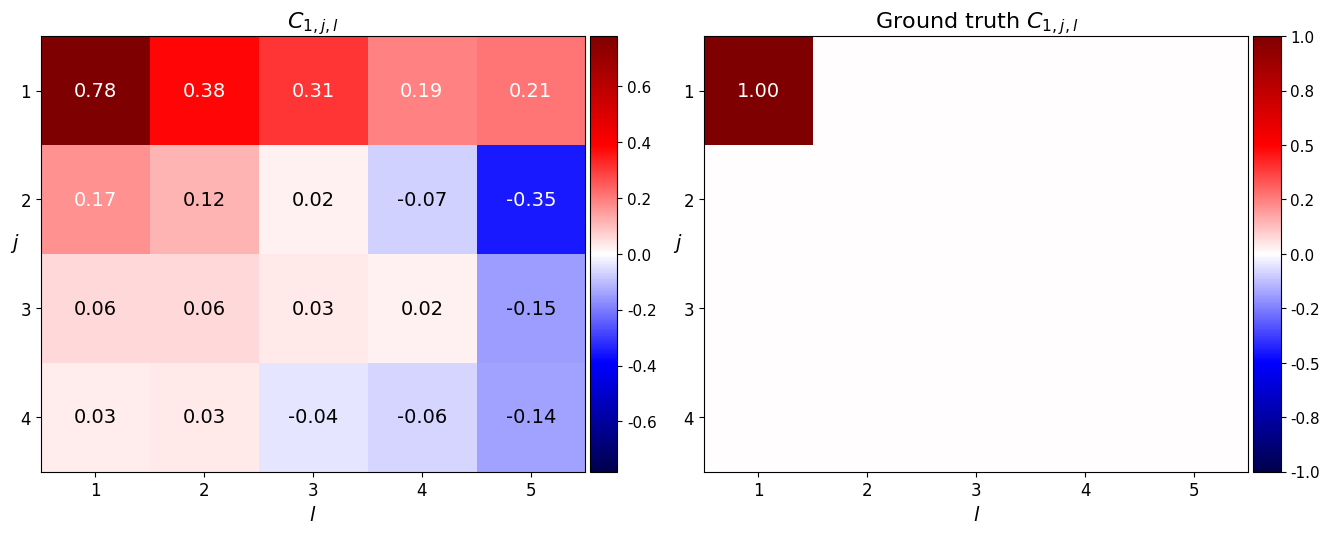

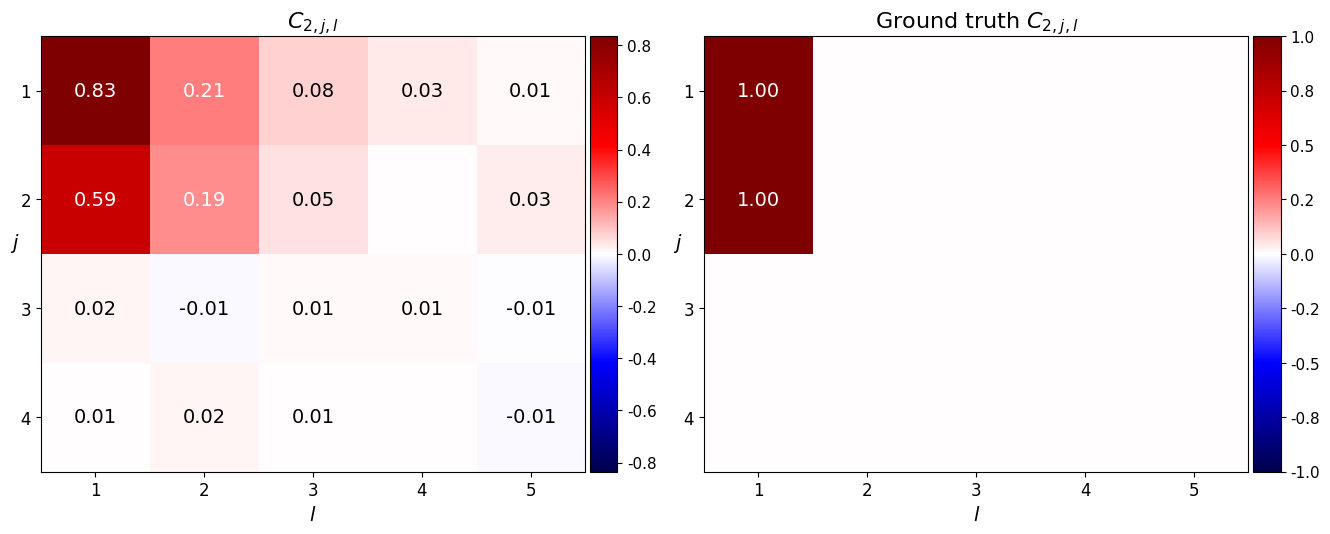

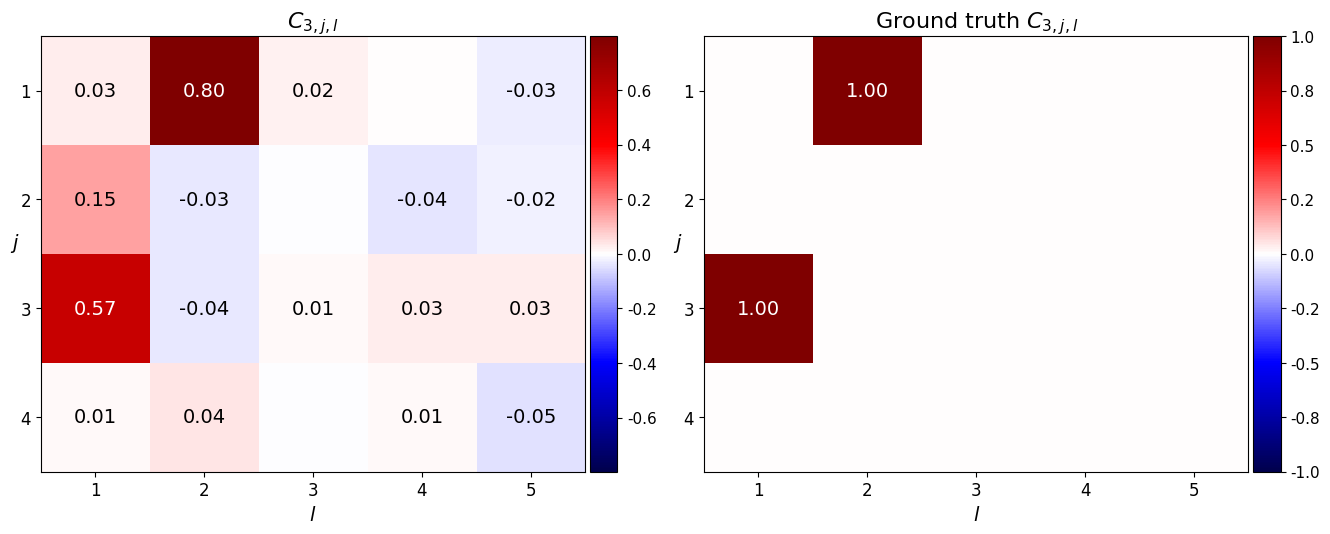

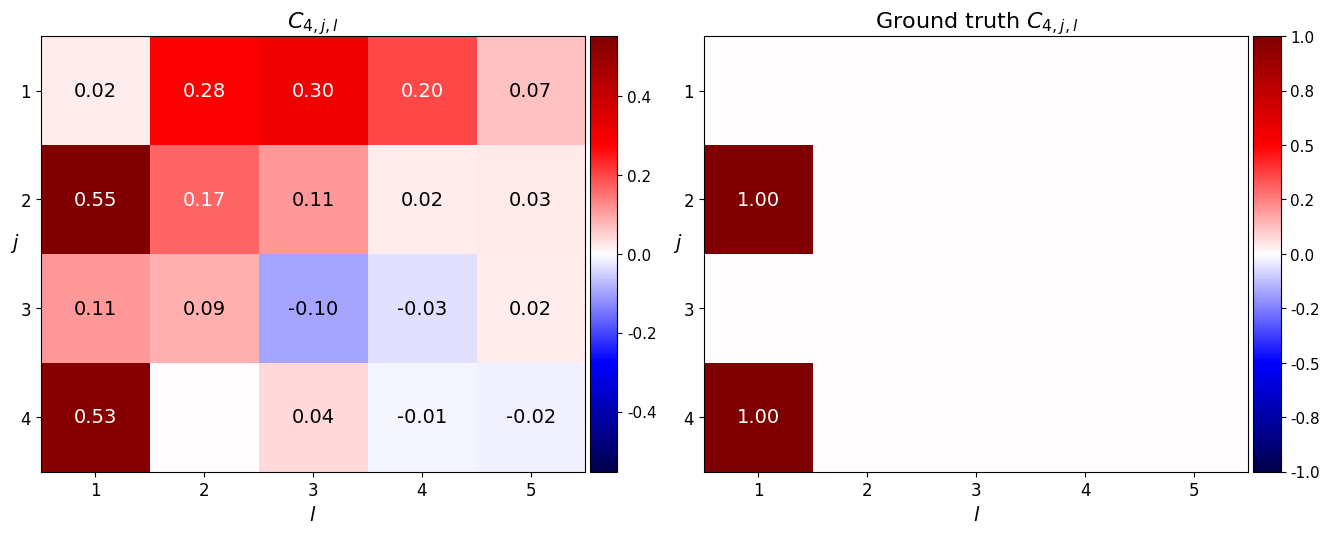

Coefficient heatmaps: hidden_U


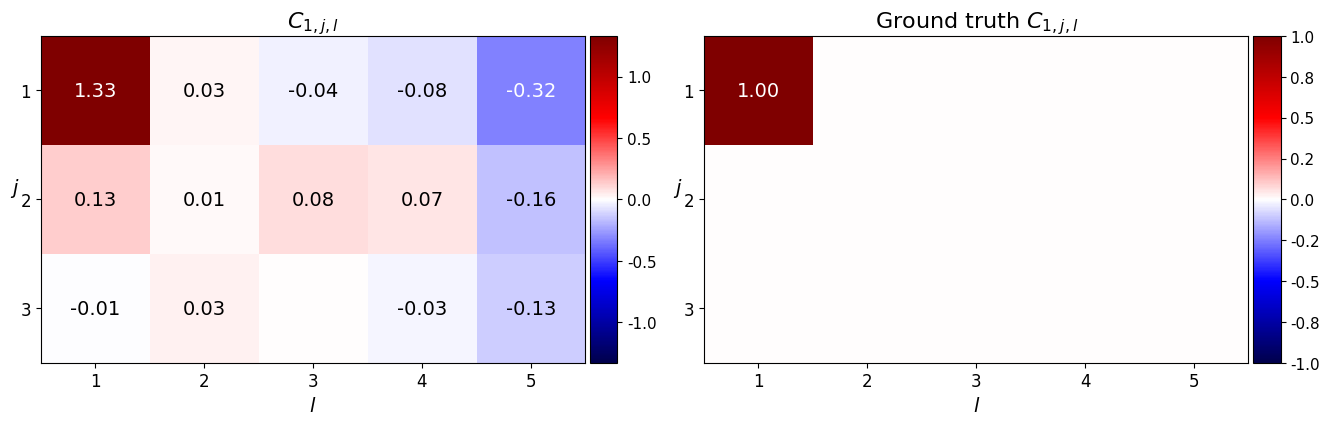

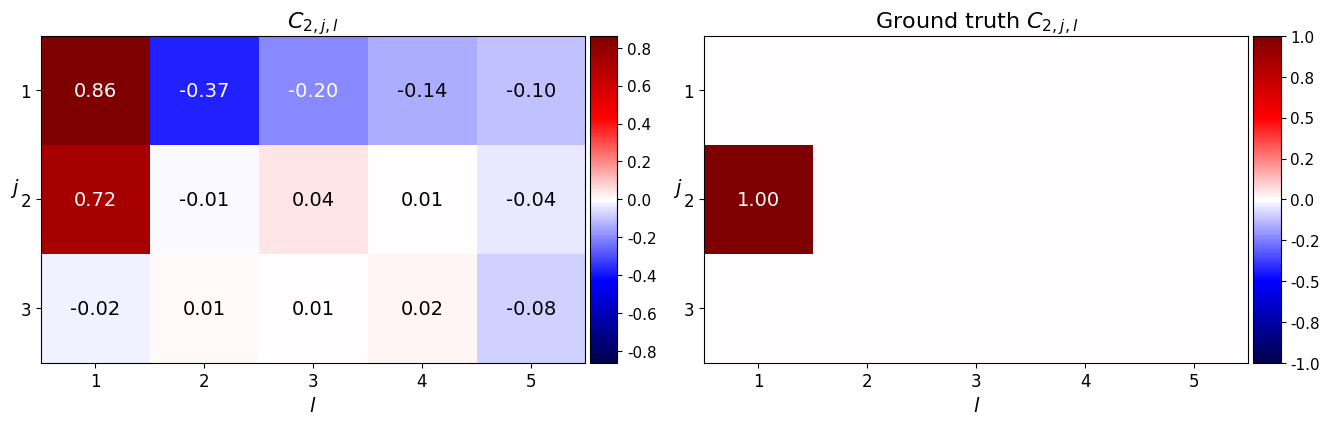

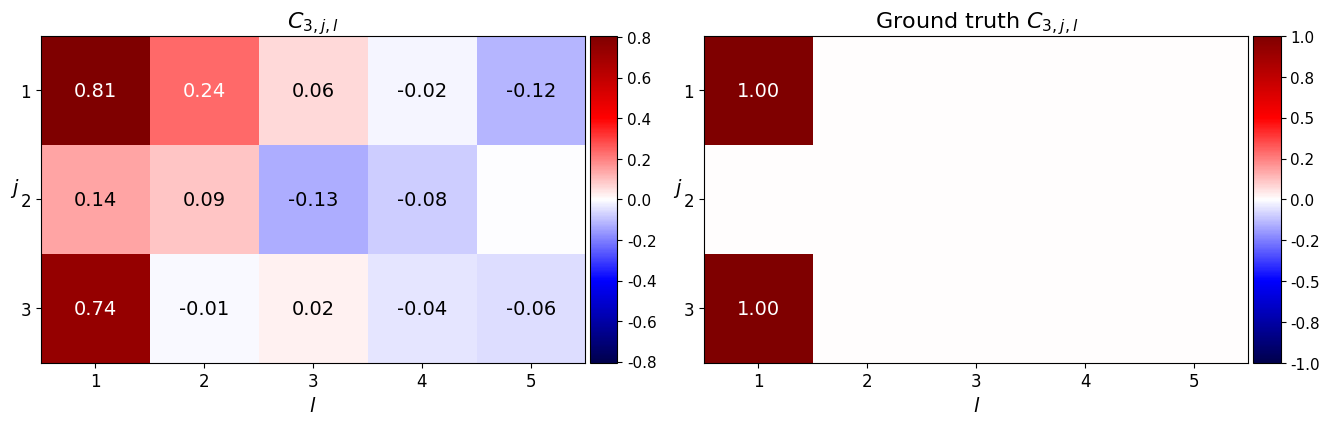

Coefficient heatmaps: hidden_U_without_seasonal


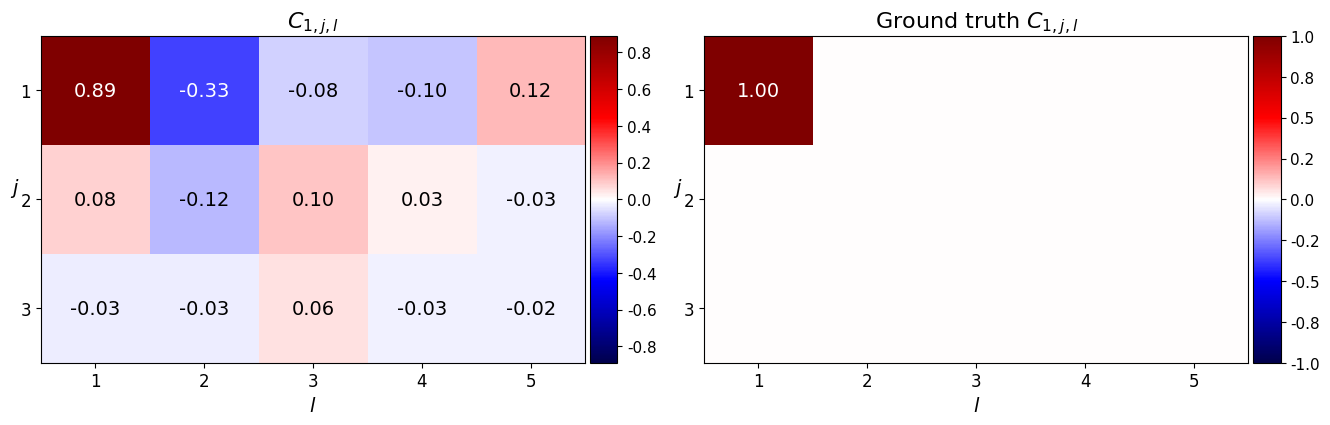

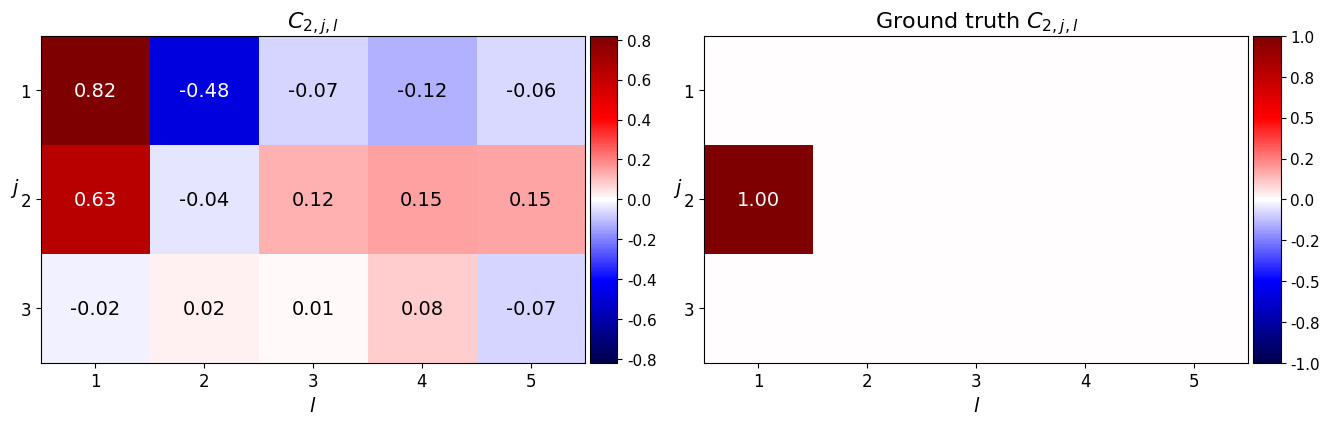

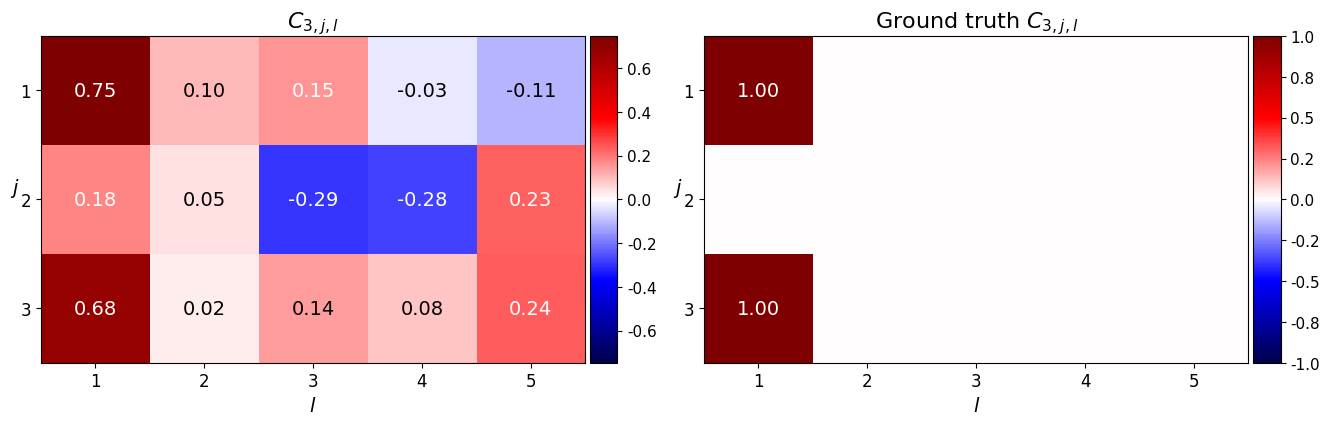

In [58]:
for case_name, case in synthetic_cases.items():
    print("=" * 80)
    print(f"Coefficient heatmaps: {case_name}")
    plot_alphas(case["stats"]["c"][1]["mean"], case["alpha_mask"], figsize=(8, 7), title=r"C", font_size=14, space=0.15, force_12=True)

# Pipeline plot testing:

In [73]:
def plot_alphas_one_canvas(
    alpha,
    ground_truth_alpha,
    cmap="seismic",
    figsize=(6, 5),
    font_size=14,
    title=r"\alpha",
    space=0.1,
    cbar_font=11,
    save_path=None,
):
    if isinstance(ground_truth_alpha, torch.Tensor):
        ground_truth_alpha = ground_truth_alpha.detach().cpu().numpy()

    n_ts, _, w_l = ground_truth_alpha.shape
    n_targets = alpha.shape[0]

    fig, axes = plt.subplots(
        n_targets,
        2,
        figsize=(figsize[0] * 2, figsize[1] * n_targets),
        gridspec_kw={"wspace": space, "hspace": space},
    )

    if n_targets == 1:
        axes = np.array([axes])

    for i in range(n_targets):
        for idx, (data, title_prefix, needs_flip) in enumerate(zip(
            [alpha[i], ground_truth_alpha[i]],
            [rf"${title}_{{{i+1},j,l}}$", rf"Ground truth ${title}_{{{i+1},j,l}}$"],
            [True, False],
        )):
            ax = axes[i, idx]

            if needs_flip:
                if data.ndim < 2:
                    raise ValueError(f"Expected 2D data, got {data.ndim}D data with shape {data.shape}")
                data = np.flip(data, axis=1)

            abs_max_value = np.max(np.abs(data))

            im = ax.imshow(
                data,
                cmap=cmap,
                vmin=-abs_max_value,
                vmax=abs_max_value,
            )

            data_rounded = np.round(data, 2)

            for ii in range(data_rounded.shape[0]):
                for jj in range(data_rounded.shape[1]):
                    value = data_rounded[ii, jj]
                    if value != 0:
                        text_color = "black" if abs(value) < 0.2 * abs_max_value else "white"
                        ax.text(
                            jj,
                            ii,
                            f"{value:.2f}",
                            ha="center",
                            va="center",
                            color=text_color,
                            fontsize=font_size,
                        )

            ax.set_title(title_prefix, fontsize=font_size + 2)
            ax.set_xlabel("$l$", fontsize=font_size)
            ax.set_ylabel("$j$", rotation=0, fontsize=font_size)

            ax.set_xticks(range(data.shape[-1]))
            ax.set_xticklabels(range(1, data.shape[-1] + 1), fontsize=font_size - 2)

            ax.set_yticks(range(data.shape[0]))
            ax.set_yticklabels(range(1, data.shape[0] + 1), fontsize=font_size - 2)

            divider = make_axes_locatable(ax)
            cax = divider.append_axes("right", size="5%", pad=0.05)
            cbar = plt.colorbar(im, cax=cax)
            cbar.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.1f"))
            cbar.ax.tick_params(labelsize=cbar_font)

    if save_path is not None:
        fig.savefig(save_path, bbox_inches="tight")
        plt.close(fig)
    else:
        plt.show()

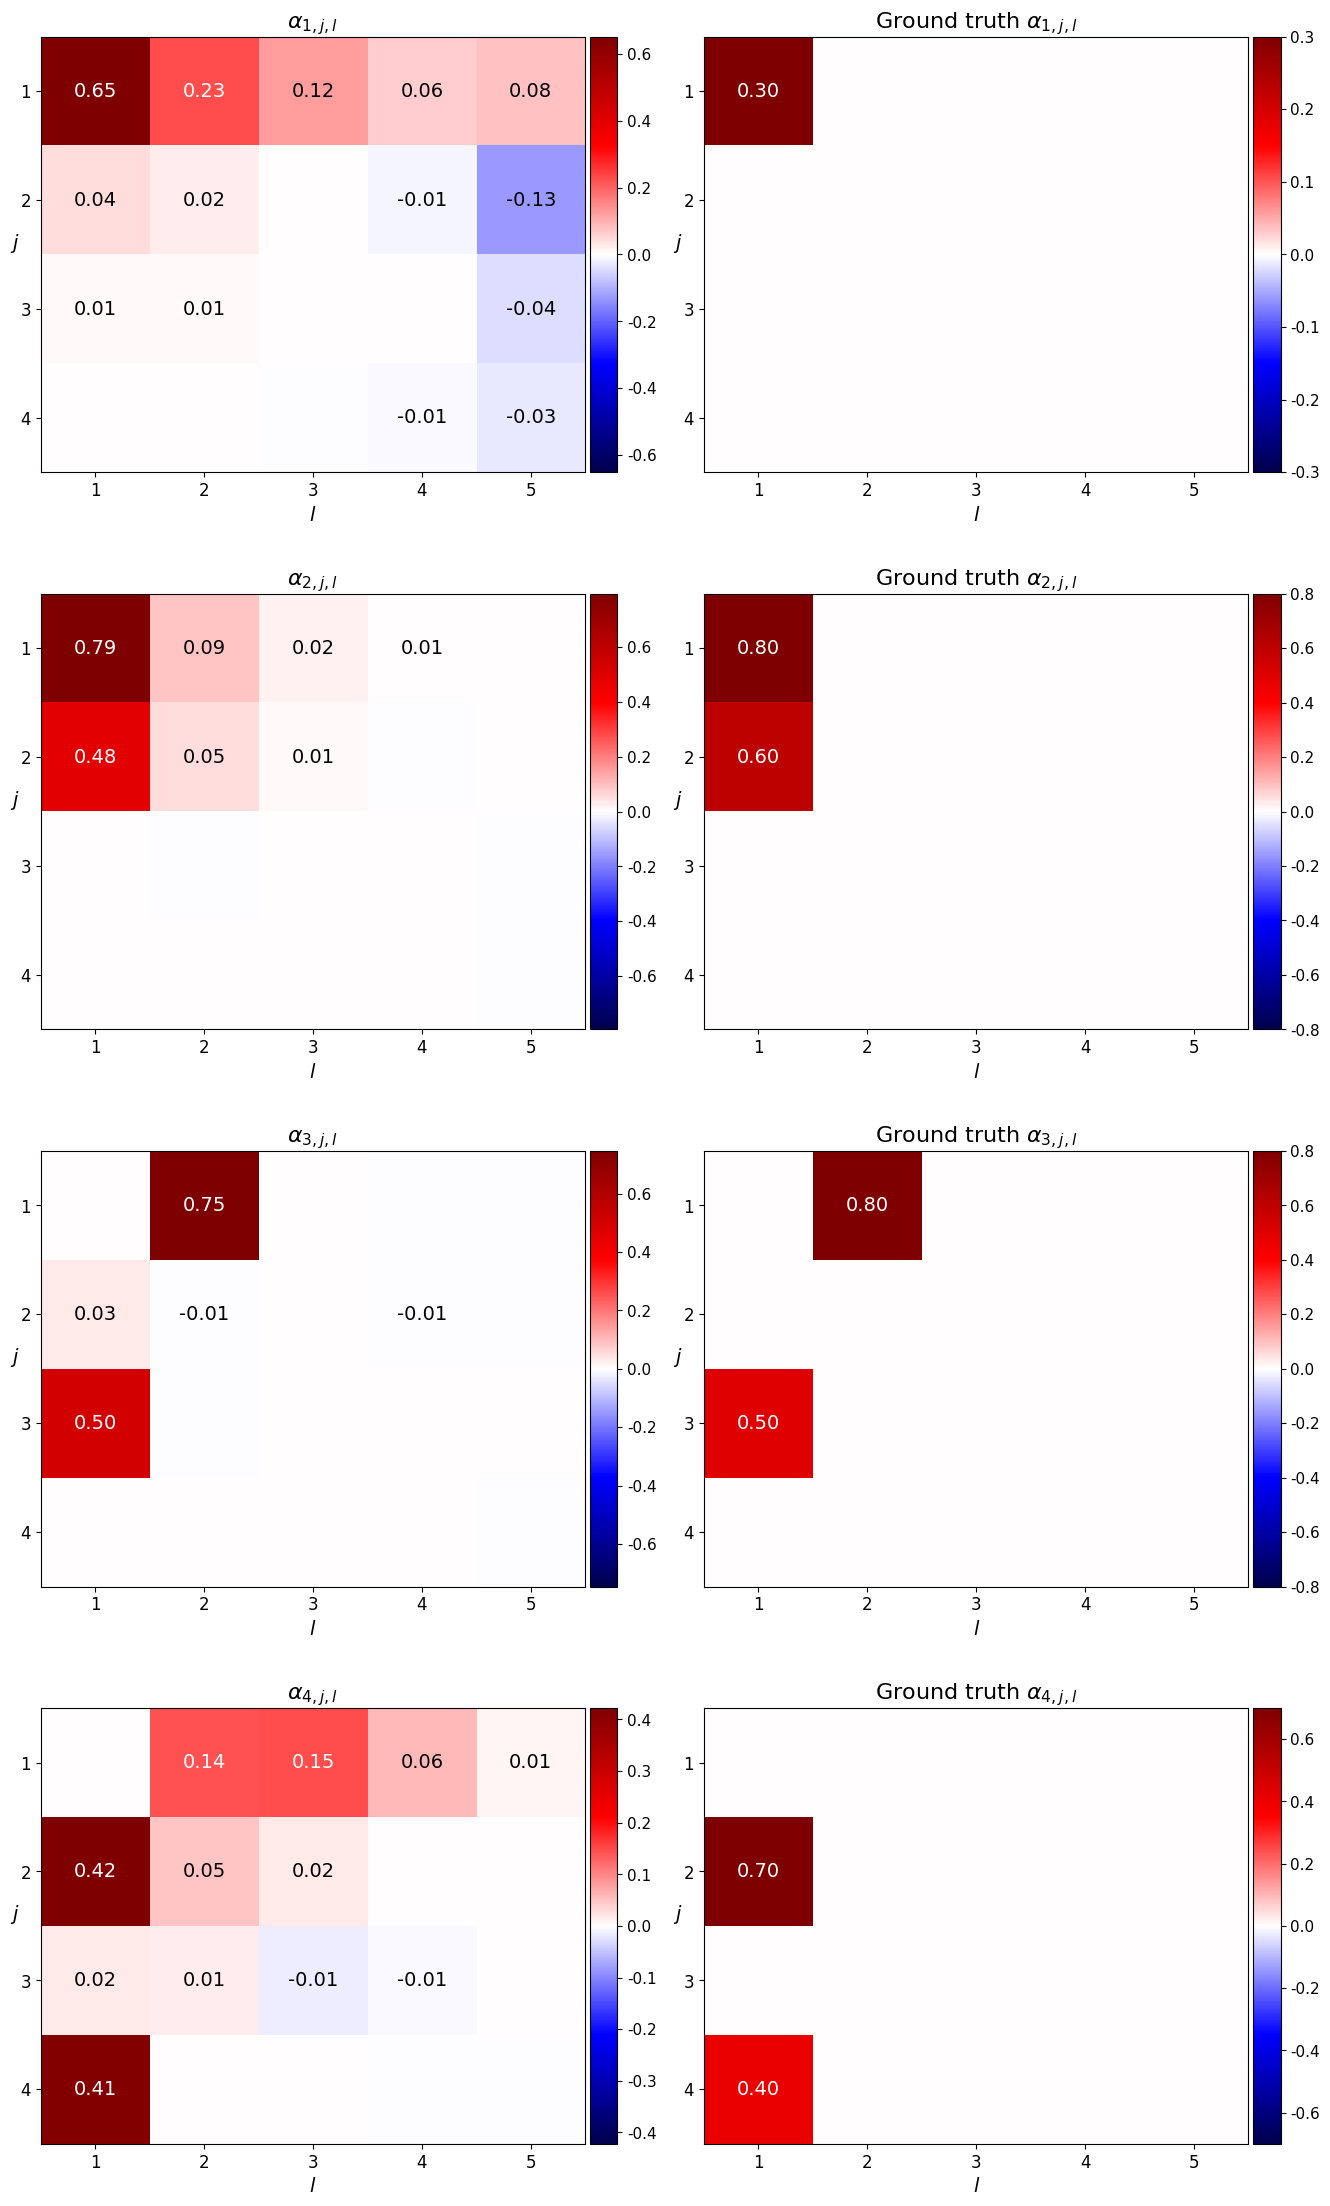

In [75]:
case_name = "observed_U"
case = synthetic_cases[case_name]

plot_alphas_one_canvas(
    case["stats"]["alpha"][1]["mean"],
    case["ground_truth_alpha"],
    figsize=(8, 7),
    font_size=14,
    space=0.15,
    save_path=None,
)

In [84]:
def plot_metric_lag_comparison(
    synthetic_cases,
    metric="alpha",
    alpha_key=1,
    save_path=None,
    cmap="seismic",
):
    case_names = ["observed_U", "hidden_U", "hidden_U_without_seasonal"]
    case_titles = ["observed U", "hidden U", "hidden U - seasonal removed"]

    estimated_by_case = []
    truth_by_case = []
    labels_by_case = []

    for case_name in case_names:
        case = synthetic_cases[case_name]

        if metric == "alpha":
            estimated = case["stats"]["alpha"][alpha_key]["mean"]
            truth = case["ground_truth_alpha"].detach().cpu().numpy()
            colorbar_label = r"$\alpha$"
        elif metric == "focuser":
            estimated = case["stats"]["f"][alpha_key]["mean"]
            truth = case["alpha_mask"].detach().cpu().numpy()
            colorbar_label = "Focuser"
        elif metric == "coefficient":
            estimated = case["stats"]["c"][alpha_key]["mean"]
            truth = case["alpha_mask"].detach().cpu().numpy()
            colorbar_label = "Coefficient"
        else:
            raise ValueError(f"Unknown metric: {metric}")

        estimated = np.flip(estimated, axis=2)

        estimated_by_case.append(estimated)
        truth_by_case.append(truth)
        labels_by_case.append(case["names"])

    n_cases = len(case_names)
    n_lags = max(values.shape[2] for values in estimated_by_case)
    n_rows = 2 * n_cases

    vmax = max(
        max(np.max(np.abs(est)), np.max(np.abs(truth)))
        for est, truth in zip(estimated_by_case, truth_by_case)
    )
    vmax = max(vmax, 1e-12)

    fig, axes = plt.subplots(
        n_rows,
        n_lags,
        figsize=(3.2 * n_lags, 2.8 * n_rows),
        constrained_layout=True,
    )

    for case_idx, (case_title, estimated, truth, labels) in enumerate(
        zip(case_titles, estimated_by_case, truth_by_case, labels_by_case)
    ):
        for row_offset, row_label, values in [
            (0, "estimated", estimated),
            (1, "ground truth", truth),
        ]:
            row_idx = 2 * case_idx + row_offset
            n_series = values.shape[0]

            for lag_idx in range(n_lags):
                ax = axes[row_idx, lag_idx]
                matrix = values[:, :, lag_idx]

                im = ax.imshow(
                    matrix,
                    cmap=cmap,
                    vmin=-vmax,
                    vmax=vmax,
                    aspect="equal",
                )

                data_rounded = np.round(matrix, 2)

                for target_idx in range(data_rounded.shape[0]):
                    for source_idx in range(data_rounded.shape[1]):
                        value = data_rounded[target_idx, source_idx]
                        if value != 0:
                            text_color = "black" if abs(value) < 0.2 * vmax else "white"
                            ax.text(
                                source_idx,
                                target_idx,
                                f"{value:.2f}",
                                ha="center",
                                va="center",
                                color=text_color,
                                fontsize=8,
                            )

                if row_idx == 0:
                    ax.set_title(f"lag {lag_idx + 1}", fontsize=12)

                if lag_idx == 0:
                    ax.set_ylabel(f"{case_title}\n{row_label}\ntarget", fontsize=10)

                ax.set_xticks(range(n_series))
                ax.set_yticks(range(n_series))
                ax.set_xticklabels(labels, fontsize=9)
                ax.set_yticklabels(labels, fontsize=9)
                ax.set_xlabel("source", fontsize=9)

                ax.set_xticks(np.arange(-0.5, n_series, 1), minor=True)
                ax.set_yticks(np.arange(-0.5, n_series, 1), minor=True)
                ax.grid(which="minor", color="black", linestyle="-", linewidth=0.4)
                ax.tick_params(which="minor", bottom=False, left=False)

    fig.colorbar(
        im,
        ax=axes,
        shrink=0.85,
        label=colorbar_label,
    )

    fig.suptitle(f"{metric}: estimated vs ground truth across cases", fontsize=14)

    if save_path is not None:
        fig.savefig(save_path, bbox_inches="tight")
        plt.close(fig)
    else:
        plt.show()

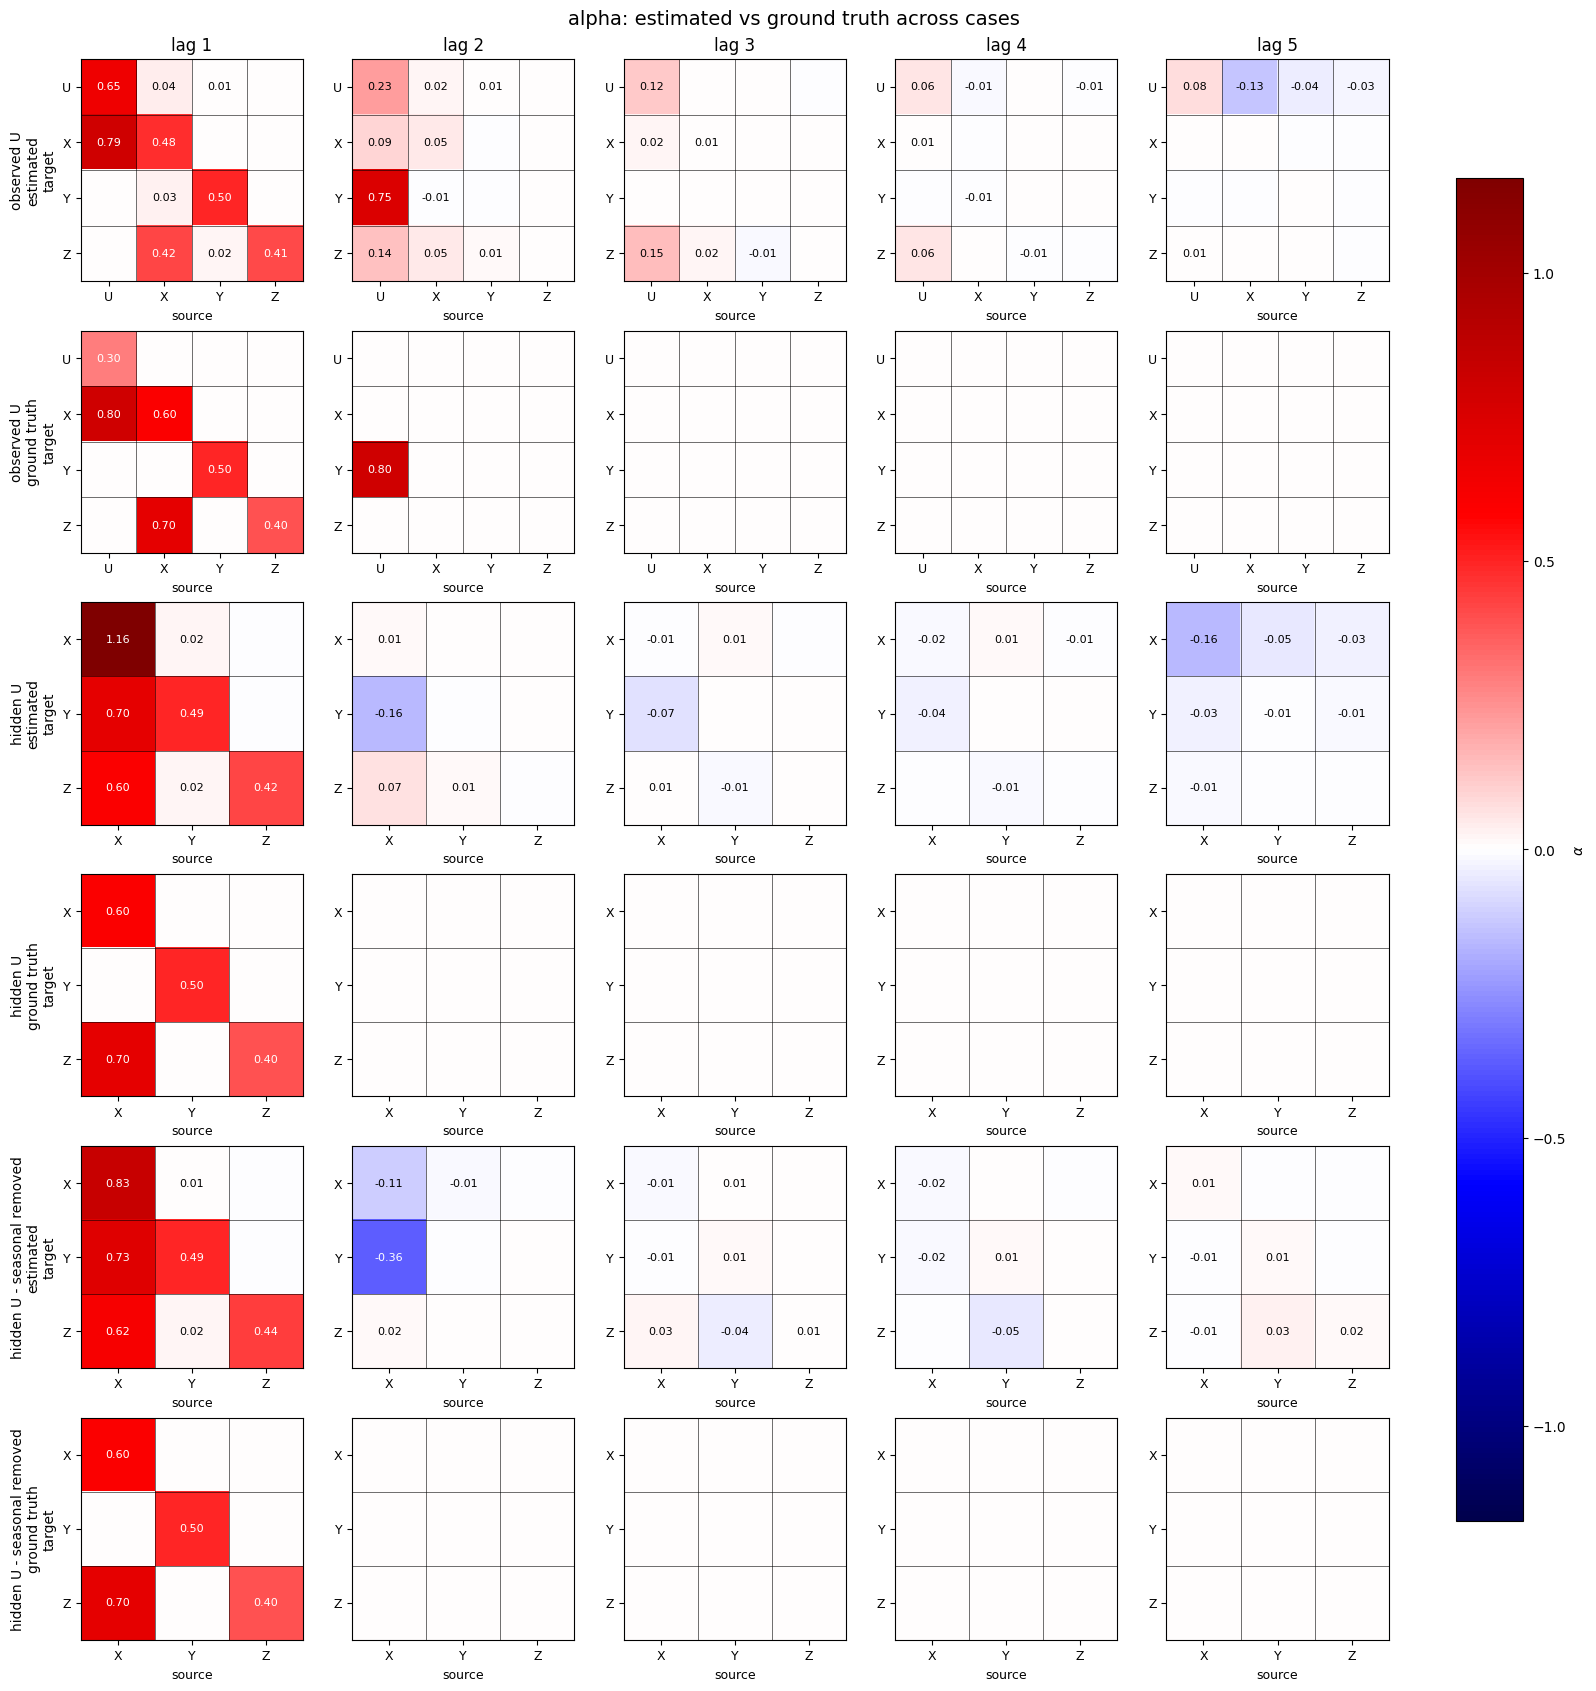

In [85]:
plot_metric_lag_comparison(
    synthetic_cases,
    metric="alpha",
    alpha_key=1,
    save_path=None,
)